<a href="https://colab.research.google.com/github/Lenfried/edh-autobuilder/blob/main/edhAutobuilder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Process data and feature engineering

In [1]:
#Get bulk data file from Scryfall
import requests
import pandas as pd
import json
all_cards = []
url = "https://api.scryfall.com/cards/search?q=st%3Aexpansion+or+st%3Acore&unique=cards&as=grid&order=name"


response = requests.get(url)
data = response.json()
all_cards.extend(data['data'])


df = pd.DataFrame(all_cards)
df.head()
df.tail(5)

,object,id,oracle_id,multiverse_ids,mtgo_id,arena_id,tcgplayer_id,cardmarket_id,name,lang,...,all_parts,frame_effects,security_stamp,promo_types,card_faces,watermark,penny_rank,resource_id,produced_mana,mtgo_foil_id
170,card,ee4336a9-c904-44a3-8cbd-a1fd5fdbcd74,2932baae-bdf1-455a-9ac4-23ba1f83e7e1,[121196],24643.0,NaN,13995.0,13602.0,Adarkar Valkyrie,en,...,NaN,NaN,NaN,NaN,NaN,NaN,14024.0,NaN,NaN,24644.0
171,card,08ae1037-6f70-41a9-b75e-98fa9a2152c8,d5ad26cc-2bdb-46b7-b8bf-dd099d5fa09b,[574723],102962.0,82295.0,282752.0,671393.0,Adarkar Wastes,en,...,NaN,NaN,oval,NaN,NaN,NaN,192.0,NaN,"[C, U, W]",NaN
172,card,c18bce4a-9afb-4b91-bc9a-d62634b0f8dd,dd66b8ab-14a9-455b-98f6-5356df72a522,[121268],24759.0,NaN,13996.0,13603.0,Adarkar Windform,en,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24760.0
173,card,af2fecd0-cb15-42d5-b652-5721bec421b2,594829d5-a5ea-4ef1-8b0e-bb1a5c62b491,[],NaN,87106.0,NaN,NaN,A-Dawnbringer Cleric,en,...,"[{'object': 'related_card', 'id': 'c00856f7-fe...",NaN,arena,"[rebalanced, alchemy]",NaN,NaN,NaN,NaN,NaN,NaN
174,card,d116839f-6a3a-4a2e-a3ab-ea177c012746,c95e75fb-2bf2-431c-b7ca-d84236bffe5c,[145992],28683.0,NaN,15406.0,17889.0,Adder-Staff Boggart,en,...,NaN,NaN,NaN,NaN,NaN,NaN,15894.0,NaN,NaN,28684.0


In [2]:
#Feature Engineering
#Using a sentence transformer, converts the csv file into vectors to be used in the genetic algorithm
import pandas as pd
import json
import numpy as np
from sklearn.preprocessing import MultiLabelBinarizer, MinMaxScaler
from sentence_transformers import SentenceTransformer
import os
from typing import List, Dict, Any

# --- Configuration ---
JSON_FILE_PATH = 'oracle-cards-20251117221017.json' # The input file
EMBEDDING_MODEL_NAME = 'all-MiniLM-L6-v2' # Sample model, can use other models as well
OUTPUT_FILE = 'model_ready_card_vectors.csv' # The final output file

# Keywords for functional categories
FUNCTIONAL_KEYWORDS = {
    'Ramp': ['add (.*) mana', 'search (.*) land', 'untap (.*) land', 'basic land'],
    'Card_Draw': ['draw (.*) card', 'look at (.*) card', 'scry', 'surveil', 'venture', 'foretell'],
    'Spot_Removal': ['destroy target creature', 'exile target creature', 'return target permanent', 'counter target spell', 'deal (.*) damage to target creature'],
    'Board_Wipe': ['destroy all creatures', 'exile all creatures', 'return all non-land', 'damage to all non-land', 'sweeper'],
    'Tutor': ['search (.*) library for (.*) card', 'find (.*) card and put (.*) hand'],
}

# --- Data Loading and Cleaning Function ---

def load_and_clean_mtg_data(file_path: str) -> pd.DataFrame:
    """
    Loads raw Scryfall data from JSON, filters for Commander legality,
    and performs the initial data cleaning and feature extraction.
    """
    if not os.path.exists(file_path):
        print(f"FATAL ERROR: Required JSON file '{file_path}' not found.")
        return pd.DataFrame()

    print(f"Loading and cleaning raw data from {file_path}...")

    # 1. Load the raw JSON data
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            raw_data: List[Dict[str, Any]] = json.load(f)
    except json.JSONDecodeError as e:
        print(f"Error decoding JSON: {e}")
        return pd.DataFrame()

    df = pd.DataFrame(raw_data)

    # --- 1. Filtering and Deduplication ---

    # Filter 1.1: Commander Legality
    df_filtered = df[
        df['legalities'].apply(lambda x: x.get('commander') == 'legal')
    ].copy()

    # Filter 1.2: Remove non-playable types (Tokens, Emblems, etc.)
    banned_types = ['Token', 'Emblem', 'Scheme', 'Vanguard', 'Conspiracy', 'Card']
    df_filtered = df_filtered[
        ~df_filtered['type_line'].str.contains('|'.join(banned_types), na=False)
    ].copy()

    # 1.3 Deduplicate: Keep one entry per unique card concept (Name)
    df_filtered.drop_duplicates(subset=['name'], keep='first', inplace=True)

    print(f"Filtered down to {len(df_filtered)} unique, Commander-legal card concepts.")

    # --- 2. Feature Extraction and Cleaning ---

    # 2.1 Process Color Identity (WUBRG string)
    def get_color_identity_string(colors):
        return ''.join(sorted(colors)) if colors else 'C'
    df_filtered['color_identity'] = df_filtered['color_identity'].apply(get_color_identity_string)

    # 2.2 Clean Text Fields (NLP Input)
    df_filtered['oracle_text_clean'] = df_filtered['oracle_text'].fillna('')
    df_filtered['power'] = df_filtered['power'].str.replace('*', '0').fillna('0').astype(str)
    df_filtered['toughness'] = df_filtered['toughness'].str.replace('*', '0').fillna('0').astype(str)

    # 2.3 Convert Numerical Fields
    df_filtered['mana_value'] = df_filtered['cmc'].fillna(0.0).astype(float)
    df_filtered['edhrec_rank'] = df_filtered['edhrec_rank'].fillna(99999).astype(int)

    # 2.4 Extract Flag Features
    df_filtered['is_legendary'] = df_filtered['type_line'].str.contains('Legendary', na=False).astype(int)

    # Select the columns needed for the engineering pipeline
    return df_filtered[[
        'name', 'oracle_id', 'type_line', 'rarity', 'color_identity',
        'mana_value', 'is_legendary', 'power', 'toughness',
        'edhrec_rank', 'oracle_text_clean'
    ]].copy()

# --- Feature Engineering Pipeline Functions ---

def create_functional_features(df: pd.DataFrame) -> pd.DataFrame:
    """Creates boolean/count features for key Commander deck functions."""
    oracle_text = df['oracle_text_clean'].str.lower()

    for category, regex_list in FUNCTIONAL_KEYWORDS.items():
        combined_regex = '|'.join(regex_list)
        df[f'is_{category}'] = oracle_text.str.contains(combined_regex, na=False).astype(int)

    return df

def generate_and_add_embeddings(df: pd.DataFrame, model_name: str) -> pd.DataFrame:
    """Generates sentence embeddings for the card's Oracle text."""
    print(f"Generating embeddings using {model_name}...")
    try:
        model = SentenceTransformer(model_name)
    except Exception as e:
        print(f"Error loading model: {e}. Skipping embedding generation.")
        print("Install 'sentence-transformers': pip install sentence-transformers")
        return df

    texts = df['oracle_text_clean'].tolist()

    embeddings = model.encode(texts, show_progress_bar=False, normalize_embeddings=True)

    embedding_df = pd.DataFrame(embeddings, index=df.index)
    embedding_df.columns = [f'embed_{i}' for i in range(embeddings.shape[1])]

    df = pd.concat([df, embedding_df], axis=1)

    return df

def feature_engineer_pipeline(df: pd.DataFrame) -> pd.DataFrame:
    """The main Scikit-learn based preprocessing pipeline."""

    # 1. Functional Features (Custom Keywords)
    df = create_functional_features(df)

    # 2. Categorical Encoding (One-Hot & Multi-Label)

    # One-Hot Encode Rarity (Nominal data)
    df = pd.get_dummies(df, columns=['rarity'], prefix='rarity')

    # Multi-Label Encode Color Identity
    mlb = MultiLabelBinarizer()
    color_identity_encoded = mlb.fit_transform([list(ci) for ci in df['color_identity']])
    color_identity_df = pd.DataFrame(color_identity_encoded, columns=[f'CI_{c}' for c in mlb.classes_], index=df.index)
    df = pd.concat([df.drop(columns=['color_identity']), color_identity_df], axis=1)

    # 3. Handle Remaining String Values
    df['power'] = pd.to_numeric(df['power'], errors='coerce').fillna(0)
    df['toughness'] = pd.to_numeric(df['toughness'], errors='coerce').fillna(0)

    # 4. Standardize/Scale Numerical Features

    # Select all numerical features (including the new functional flags)
    numerical_features = [
        'mana_value', 'power', 'toughness', 'edhrec_rank', 'is_legendary'
    ]
    numerical_features.extend([col for col in df.columns if col.startswith('is_')])

    # Apply MinMax Scaling to bring all features to a 0-1 range
    scaler = MinMaxScaler()
    df[numerical_features] = scaler.fit_transform(df[numerical_features])

    # 5. Drop source columns
    df.drop(columns=['oracle_id', 'type_line'], inplace=True)

    return df

if __name__ == '__main__':
    # --- 1. Load and Clean from JSON ---
    df_raw = load_and_clean_mtg_data(JSON_FILE_PATH)

    if not df_raw.empty:
        # --- 2. Generate NLP Embeddings ---
        df_embedded = generate_and_add_embeddings(df_raw.copy(), EMBEDDING_MODEL_NAME)

        # --- 3. Run the Final Scikit-learn Feature Engineering Pipeline ---
        df_model_ready = feature_engineer_pipeline(df_embedded.copy())

        # --- Final Output ---
        print("\n--- Final Model-Ready Feature Vector (Sample) ---")
        # Display features and their types
        print(df_model_ready[['name', 'mana_value', 'CI_B', 'is_Ramp', 'embed_0', 'embed_1']].head().to_markdown(index=False))
        print(f"\nTotal Model-Ready Cards: {df_model_ready.shape[0]}")
        print(f"Final Feature Vector Size (Dimensions): {df_model_ready.shape[1]}")

        # Save the final data set
        df_model_ready.to_csv(OUTPUT_FILE, index=False)
        print(f"\n✅ All card features saved to '{OUTPUT_FILE}' for model training.")

FATAL ERROR: Required JSON file 'oracle-cards-20251117221017.json' not found.


In [3]:
import pandas as pd
import numpy as np

# Load the processed data
df = pd.read_csv('model_ready_card_vectors.csv')

# Extract only the embedding columns
embedding_cols = [col for col in df.columns if col.startswith('embed_')]
embeddings = df[embedding_cols].to_numpy()

# Save to .npy file
np.save('card_embeddings.npy', embeddings)

print(f"Embeddings saved to 'card_embeddings.npy' with shape {embeddings.shape}")

FileNotFoundError: [Errno 2] No such file or directory: 'model_ready_card_vectors.csv'

In [4]:
from google.colab import drive
import os

print("Mounting Google Drive...")
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/MTGCISE'
print(f"DRIVE_PATH set to: {DRIVE_PATH}")

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DRIVE_PATH set to: /content/drive/MyDrive/MTGCISE


In [5]:
#Check embedding quality
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from typing import List
import os


# CLEANED_CSV_PATH = os.path.join(DRIVE_PATH, 'cleaned_mtg_card_features.csv') # This line caused NameError

# 1. SETUP: Load your data
# Assuming 'cleaned_mtg_card_features.csv' exists from previous steps
# and 'embeddings.npy' is the output of your Sentence-Transformer model
def perform_nn_check(csv_path: str, embeddings_path: str, query_card_name: str, k: int = 5):
    """
    Finds the K-Nearest Neighbors for a specific card based on rule text embeddings.
    """
    df = pd.read_csv(csv_path)
    # Ensure embeddings are loaded as a 2D numpy array
    embeddings = np.load(embeddings_path)

    if query_card_name not in df['name'].values:
        print(f"Error: {query_card_name} not found in the dataset.")
        return

    # Initialize Nearest Neighbors model using Cosine Similarity
    # Cosine is better than Euclidean for NLP embeddings
    nn = NearestNeighbors(n_neighbors=k+1, metric='cosine', algorithm='brute')
    nn.fit(embeddings)

    # Find index of query card
    query_idx = df[df['name'] == query_card_name].index[0]
    query_vec = embeddings[query_idx].reshape(1, -1)

    # Find neighbors
    distances, indices = nn.kneighbors(query_vec)

    print(f"\n--- Neighbors for '{query_card_name}' ---")
    print(f"Oracle Text: {df.iloc[query_idx]['oracle_text_clean'][:100]}...\n")

    for i in range(1, len(distances[0])): # Start from 1 to skip the card itself
        idx = indices[0][i]
        sim_score = 1 - distances[0][i] # Convert distance to similarity
        name = df.iloc[idx]['name']
        text = df.iloc[idx]['oracle_text_clean'][:100]
        print(f"{i}. {name} (Similarity: {sim_score:.4f})")
        print(f"   Text: {text}...\n")

# 2. VISUALIZATION: Projecting to 2D
def visualize_embedding_clusters(df: pd.DataFrame, embeddings: np.array, sample_size: int = 500):
    """
    Uses PCA to plot a sample of card embeddings in 2D space.
    """
    # Sample data to avoid a messy plot
    indices = np.random.choice(range(len(embeddings)), min(sample_size, len(embeddings)), replace=False)
    sampled_embeddings = embeddings[indices]
    sampled_names = df.iloc[indices]['name'].values

    # Reduce dimensions to 2D
    pca = PCA(n_components=2)
    reduced_vecs = pca.fit_transform(sampled_embeddings)

    plt.figure(figsize=(12, 8))
    plt.scatter(reduced_vecs[:, 0], reduced_vecs[:, 1], alpha=0.5, c='blue', edgecolors='white')

    # Add labels to a few points to see if related cards are near each other
    for i in range(10): # Label first 10 sampled cards
        plt.annotate(sampled_names[i], (reduced_vecs[i, 0], reduced_vecs[i, 1]), fontsize=9)

    plt.title("2D PCA Projection of MTG Card Embeddings")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

if __name__ == "__main__":
    # Example usage (Replace with your actual paths)
    # These paths now correctly use the globally defined DRIVE_PATH
    CSV_FILE = os.path.join(DRIVE_PATH, 'model_ready_card_vectors.csv') # Assuming this is the correct output from FE
    EMBEDDINGS_FILE = os.path.join(DRIVE_PATH, 'card_embeddings.npy')

    # Example Test Card
    perform_nn_check(CSV_FILE, EMBEDDINGS_FILE, "Rampant Growth")


--- Neighbors for 'Rampant Growth' ---
Oracle Text: Search your library for a basic land card, put that card onto the battlefield tapped, then shuffle....

1. Natural Connection (Similarity: 0.9935)
   Text: Search your library for a basic land card, put it onto the battlefield tapped, then shuffle....

2. Shared Roots (Similarity: 0.9935)
   Text: Search your library for a basic land card, put it onto the battlefield tapped, then shuffle....

3. Untamed Wilds (Similarity: 0.9738)
   Text: Search your library for a basic land card, put that card onto the battlefield, then shuffle....

4. Explosive Vegetation (Similarity: 0.9688)
   Text: Search your library for up to two basic land cards, put them onto the battlefield tapped, then shuff...

5. Cultivate (Similarity: 0.9414)
   Text: Search your library for up to two basic land cards, reveal those cards, put one onto the battlefield...



## Setup & Candidate Filtering for GA

Helper functions to filter the card pool by the Commander's color identity and rank the remaining cards by similarity to a user's prompt.


In [6]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import warnings
import logging
from transformers import logging as transformers_logging

# 1. Setup Logging/Warning Suppression
# Suppress the "BertModel LOAD REPORT" and other info logs to ensure clean output
transformers_logging.set_verbosity_error()
logging.getLogger("sentence_transformers").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")

# 2. Load Data
try:
    df = pd.read_csv('model_ready_card_vectors.csv')
    embeddings = np.load('card_embeddings.npy')
except FileNotFoundError:
    print("Data files not found. Please ensure previous steps were executed.")
    df = pd.DataFrame()
    embeddings = np.array([])

# Initialize the model
if not df.empty:
    model = SentenceTransformer('all-MiniLM-L6-v2')

    def get_commander_color_identity(commander_name, df):
        """
        Locates the commander in the DataFrame and returns its color identity string.
        Handles exact matches and MDFC names (e.g., "Name // Name").
        """
        # Ensure name column is string
        df['name'] = df['name'].astype(str)

        # Try exact match first
        matches = df[df['name'] == commander_name]

        # If no exact match, try identifying it as the front face of a split/MDFC card
        if matches.empty:
            # Search for names starting with "Commander Name //"
            prefix = commander_name + " //"
            matches = df[df['name'].str.startswith(prefix)]

        if matches.empty:
            # Fallback: simple containment check
            matches = df[df['name'].str.contains(commander_name, regex=False)]

        if matches.empty:
            raise ValueError(f"Commander '{commander_name}' not found in dataset.")

        # Take the first match
        commander_row = matches.iloc[0]

        # Reconstruct color identity from One-Hot Encoded columns
        colors = []
        for color in ['W', 'U', 'B', 'R', 'G']:
            col_name = f'CI_{color}'
            if col_name in df.columns and commander_row[col_name] == 1:
                colors.append(color)

        return ''.join(colors) if colors else 'C'

    def filter_by_color_identity(commander_color_id, df):
        """
        Filters the DataFrame to include only cards whose color identity is a subset of the commander's.
        """
        # 1. Identify which colors are NOT allowed
        allowed_colors = set(commander_color_id)
        all_colors = ['W', 'U', 'B', 'R', 'G']
        forbidden_colors = [c for c in all_colors if c not in allowed_colors]

        # 2. Filter out cards that have any forbidden color
        mask = pd.Series([True] * len(df), index=df.index)

        for color in forbidden_colors:
            col_name = f'CI_{color}'
            if col_name in df.columns:
                mask = mask & (df[col_name] == 0)

        return df[mask].copy()

    def get_candidate_pool(prompt, filtered_df, embeddings_matrix, embedding_model, top_k=1000):
        """
        Returns indices of the top_k cards most similar to the prompt from the filtered pool.
        """
        if filtered_df.empty:
            return []

        # 1. Encode the user's prompt
        prompt_embedding = embedding_model.encode([prompt])

        # 2. Get embeddings for the filtered cards only
        filtered_indices = filtered_df.index.tolist()
        filtered_embeddings = embeddings_matrix[filtered_indices]

        # 3. Calculate Similarity
        # shape: (1, n_filtered_cards)
        similarities = cosine_similarity(prompt_embedding, filtered_embeddings).flatten()

        # 4. Get Top K indices relative to the FILTERED list
        top_k = min(top_k, len(filtered_indices))
        # argsort sorts ascending, so we take the last top_k and reverse them
        specific_indices = np.argsort(similarities)[-top_k:][::-1]

        # 5. Map back to original DataFrame/Embedding indices
        original_indices = [filtered_indices[i] for i in specific_indices]

        return original_indices

    # --- Test the Logic ---
    try:
        commander = "Toralf, God of Fury"
        prompt = "Big damage spells and red chaos"

        # 1. Get Color Identity (Should now handle MDFC names)
        cid = get_commander_color_identity(commander, df)
        print(f"Commander found: {commander}")
        print(f"Identity: {cid}")

        # 2. Filter Cards
        legal_cards_df = filter_by_color_identity(cid, df)
        print(f"Legal cards in pool: {len(legal_cards_df)}")

        # 3. Get Candidate Pool based on prompt
        pool_indices = get_candidate_pool(prompt, legal_cards_df, embeddings, model, top_k=5)

        print(f"\nTop 5 Candidates for prompt '{prompt}':")
        for idx in pool_indices:
            print(f"- {df.iloc[idx]['name']}")

    except Exception as e:
        print(f"Test failed: {e}")

Data files not found. Please ensure previous steps were executed.


## Operators for the Genetic Algorithm


In [7]:
import numpy as np
import random

def create_individual(candidate_pool, target_size=99):
    """
    Creates a random deck of target_size unique card indices from the candidate pool.
    """
    # Check if the pool has enough cards
    if len(candidate_pool) < target_size:
        raise ValueError(f"Candidate pool must have at least {target_size} cards.")

    # Randomly select target_size unique cards
    deck = np.random.choice(candidate_pool, target_size, replace=False)
    return deck.tolist()

def crossover(parent1, parent2, target_size=99):
    """
    Creates a child deck by combining parts of two parent decks.
    Ensures the child has exactly target_size unique cards.
    """
    # 1. Take a random slice from Parent 1 (e.g., roughly half)
    # We'll make the split point proportional to the target size
    min_split = int(target_size * 0.4)
    max_split = int(target_size * 0.6)
    split_point = np.random.randint(min_split, max_split)

    child = parent1[:split_point]

    # 2. Fill the rest from Parent 2, avoiding duplicates
    current_cards = set(child)
    for card in parent2:
        if card not in current_cards:
            child.append(card)
            current_cards.add(card)
            if len(child) == target_size:
                break

    # Fallback: if we run out of unique cards in parent2 (unlikely if parents are valid),
    # we might need to fill from the general pool, but for now assuming parents are sufficient.
    return child

def mutate(deck, candidate_pool, mutation_rate=0.05):
    """
    Randomly swaps cards in the deck with new ones from the candidate pool.
    Respects the current size of the deck.
    """
    deck_set = set(deck)
    pool_array = np.array(candidate_pool)

    # Iterate through the deck by index to allow modification
    for i in range(len(deck)):
        if np.random.rand() < mutation_rate:
            # Find a replacement card that is NOT already in the deck
            for _ in range(10):
                new_card = np.random.choice(pool_array)
                if new_card not in deck_set:
                    deck_set.remove(deck[i])
                    deck[i] = new_card
                    deck_set.add(new_card)
                    break
    return deck

def selection(population, fitness_scores, top_k):
    """
    Selects the top_k individuals from the population based on fitness scores.
    Assumes fitness_scores aligns with population indices.
    """
    # Sort indices by fitness in descending order
    sorted_indices = np.argsort(fitness_scores)[::-1]

    # Select top K indices
    top_indices = sorted_indices[:top_k]

    # Return the actual decks
    return [population[i] for i in top_indices]

# --- Test Block ---
if __name__ == "__main__":
    print("Testing Updated Genetic Operators with Target Size = 61...")

    # Dummy candidate pool (indices 0 to 999)
    dummy_pool = list(range(1000))
    TARGET_SIZE = 61

    # 1. Test Creation
    deck1 = create_individual(dummy_pool, target_size=TARGET_SIZE)
    deck2 = create_individual(dummy_pool, target_size=TARGET_SIZE)
    print(f"Deck 1 size: {len(deck1)}, Unique: {len(set(deck1)) == TARGET_SIZE}")

    # 2. Test Crossover
    child = crossover(deck1, deck2, target_size=TARGET_SIZE)
    print(f"Child size: {len(child)}, Unique: {len(set(child)) == TARGET_SIZE}")

    # 3. Test Mutation
    mutated_child = mutate(child[:], dummy_pool, mutation_rate=0.1)
    diff = len(set(child) - set(mutated_child))
    print(f"Mutated size: {len(mutated_child)}, Unique: {len(set(mutated_child)) == TARGET_SIZE}")
    print(f"Cards changed after mutation: {diff}")

    print("Test Complete.")

Testing Updated Genetic Operators with Target Size = 61...
Deck 1 size: 61, Unique: True
Child size: 61, Unique: True
Mutated size: 61, Unique: True
Cards changed after mutation: 5
Test Complete.


## Main Evolution Loop



In [1]:
import numpy as np
import random
import pandas as pd

def run_genetic_algorithm(commander_name, prompt, df, embeddings, model, generations=30, population_size=40, mutation_rate=0.05, deck_size=61):
    """
    Main loop for the EDH Deck Generation Genetic Algorithm.
    The deck size has been set to 61 non-lands as a default.
    """
    print(f"--- Starting GA for Commander: {commander_name} ---")
    print(f"Prompt: \"{prompt}\"")
    print(f"Target Deck Size (Non-Land): {deck_size}")

    # 1. Setup: Find Commander Index
    matches = df[df['name'] == commander_name]
    if matches.empty:
        prefix = commander_name + " //"
        matches = df[df['name'].str.startswith(prefix)]
    if matches.empty:
        matches = df[df['name'].str.contains(commander_name, regex=False)]

    if matches.empty:
        raise ValueError(f"Commander '{commander_name}' not found.")

    commander_idx = matches.index[0]
    actual_name = df.iloc[commander_idx]['name']
    print(f"Identified Commander: {actual_name} (Index: {commander_idx})")

    # 2. Filter Candidate Pool
    cid = get_commander_color_identity(actual_name, df)
    print(f"Commander Color Identity: {cid}")

    legal_df = filter_by_color_identity(cid, df)
    print(f"Legal Card Pool Size: {len(legal_df)}")

    candidate_pool = get_candidate_pool(prompt, legal_df, embeddings, model, top_k=1000)
    if len(candidate_pool) < deck_size:
        raise ValueError(f"Not enough legal cards found ({len(candidate_pool)}) to build a deck of size {deck_size}. Try a broader prompt.")
    print(f"Selected Top {len(candidate_pool)} Candidates based on prompt similarity.")

    # 3. Initialize Population with target_size
    population = [create_individual(candidate_pool, target_size=deck_size) for _ in range(population_size)]

    best_deck = None
    best_score_overall = -1.0

    # 4. Evolution Loop
    for gen in range(generations):
        fitness_scores = []

        # Calculate Fitness
        for deck in population:
            # Fitness function handles list of indices regardless of length
            score = calculate_deck_optimization(deck, commander_idx, embeddings, df)
            fitness_scores.append(score)

        # Track Best
        gen_best_idx = np.argmax(fitness_scores)
        gen_best_score = fitness_scores[gen_best_idx]

        if gen_best_score > best_score_overall:
            best_score_overall = gen_best_score
            best_deck = population[gen_best_idx]

        if (gen + 1) % 5 == 0 or gen == 0:
            print(f"Generation {gen+1}/{generations} - Best Fitness: {gen_best_score:.4f}")

        # Selection (Elitism)
        num_elites = max(2, int(population_size * 0.25))
        elites = selection(population, fitness_scores, top_k=num_elites)

        # Next Generation
        next_gen = elites.copy()

        while len(next_gen) < population_size:
            parent1 = random.choice(elites)
            parent2 = random.choice(elites)

            # Crossover with target_size
            child = crossover(parent1, parent2, target_size=deck_size)

            # Mutation (respects current size)
            child = mutate(child, candidate_pool, mutation_rate)

            next_gen.append(child)

        population = next_gen

    # 5. Result
    print(f"\nFinal Best Fitness: {best_score_overall:.4f}")
    best_deck_names = df.iloc[best_deck]['name'].tolist()
    return best_deck_names

# --- Test Block ---
if __name__ == "__main__":
    try:
        print("\n--- Running System Test with 61 Cards ---")
        test_deck_61 = run_genetic_algorithm(
            commander_name="Toralf, God of Fury",
            prompt="Burn spells and damage amplification",
            df=df,
            embeddings=embeddings,
            model=model,
            generations=3,
            population_size=10,
            deck_size=61
        )
        print(f"\nGenerated Deck Size: {len(test_deck_61)}")
        print(f"Sample: {test_deck_61[:5]}")
    except Exception as e:
        print(f"System Test Failed: {e}")


--- Running System Test with 61 Cards ---
System Test Failed: name 'df' is not defined


## Wrapper function

In [22]:
import math
import collections # Added for Counter

def generate_edh_deck(commander_name, prompt):
    """
    User-friendly wrapper to generate an EDH deck based on a commander and a theme prompt.
    Generates 61 non-land cards via GA and appends 38 Basic Lands based on color identity.
    """
    # Default GA parameters
    GENERATIONS = 50
    POPULATION_SIZE = 50
    NON_LAND_COUNT = 61
    TOTAL_DECK_SIZE = 99
    LAND_COUNT = TOTAL_DECK_SIZE - NON_LAND_COUNT

    print(f"\n{'='*60}")
    print(f" COMMANDER DECK GENERATOR")
    print(f"{'='*60}")
    print(f"Commander: {commander_name}")
    print(f"Theme:     {prompt}")
    print(f"Target:    {NON_LAND_COUNT} Spells + {LAND_COUNT} Lands")
    print(f"{'='*60}\n")

    try:
        # 1. Run the GA for Non-Land Cards
        best_deck_names = run_genetic_algorithm(
            commander_name=commander_name,
            prompt=prompt,
            df=df,
            embeddings=embeddings,
            model=model,
            generations=GENERATIONS,
            population_size=POPULATION_SIZE,
            deck_size=NON_LAND_COUNT
        )

        # 2. Generate Mana Base
        # Get Color Identity again to determine lands
        cid = get_commander_color_identity(commander_name, df)

        # Map colors to Basic Land names
        land_map = {
            'W': 'Plains',
            'U': 'Island',
            'B': 'Swamp',
            'R': 'Mountain',
            'G': 'Forest',
            'C': 'Wastes' # Fallback for colorless
        }

        colors = [c for c in cid if c in land_map]
        if not colors:
            colors = ['C'] # Colorless case

        num_colors = len(colors)
        base_count = LAND_COUNT // num_colors
        remainder = LAND_COUNT % num_colors

        lands = []
        for i, color_code in enumerate(colors):
            count = base_count + (1 if i < remainder else 0)
            land_name = land_map[color_code]
            lands.extend([land_name] * count)

        # 3. Combine and Display
        final_deck = best_deck_names + lands

        print(f"\n{'='*60}")
        print(f" OPTIMIZATION COMPLETE")
        print(f"{'='*60}")
        print(f"Full {len(final_deck)}-Card Optimized Deck List for {commander_name}:")

        print("\n--- Spells (61) ---")
        # Group and print spells by quantity
        spell_counts = collections.Counter(best_deck_names)
        for card, count in spell_counts.most_common():
            print(f"{count} {card}")

        print("\n--- Lands (38) ---")
        # Group and print lands by quantity
        land_counts = collections.Counter(lands)
        for land, count in land_counts.most_common():
            print(f"{count} {land}")

        return final_deck

    except Exception as e:
        print(f"\nERROR: {e}")
        import traceback
        traceback.print_exc()
        return []

# --- Execution ---
if __name__ == "__main__":
    # Example Run with the requested fix
    final_deck = generate_edh_deck(
        commander_name="Atraxa, Praetors' Voice",
        prompt="Proliferate and +1/+1 counters"
    )


 COMMANDER DECK GENERATOR
Commander: Atraxa, Praetors' Voice
Theme:     Proliferate and +1/+1 counters
Target:    61 Spells + 38 Lands

--- Starting GA for: Atraxa, Praetors' Voice ---
Optimization Weights: {'alignment': 0.85, 'cohesion': 0.1, 'structure': 0.05}
Gen 0: 0.3772
Gen 10: 0.4168
Gen 20: 0.4319
Gen 30: 0.4383
Gen 40: 0.4428
Final Score: 0.4428

 OPTIMIZATION COMPLETE
Full 99-Card Optimized Deck List for Atraxa, Praetors' Voice:

--- Spells (61) ---
1 Shield Sphere
1 Expanding Ooze
1 Snapping Sailback
1 Water Tribe Captain
1 Ajani's Pridemate
1 Strangleroot Geist
1 Nissa's Judgment
1 Etherwrought Page
1 Arcbound Ravager
1 Fire Nation Engineer
1 Crocodile of the Crossing
1 Qala, Ajani's Pridemate
1 Lightwalker
1 Vraska, Regal Gorgon
1 Huatli's Raptor
1 Vampire Scrivener
1 Packsong Pup
1 Vivisurgeon's Insight
1 Embalmed Brawler
1 Viral Drake
1 Sarulf, Realm Eater
1 Defend the Campus
1 Scion of the Swarm
1 Marketback Walker
1 Faithful Watchdog
1 Dromar's Charm
1 Graypelt Hunter

Sub-function to calculate the number of lands needed based on the color distribution of the non-land cards.


In [3]:
def calculate_land_distribution(deck_names, df, commander_identity, total_lands=38):
    """
    Calculates the land base, including 'Command Tower' and relevant dual lands
    for multicolored decks, then fills the rest with Basic Lands based on pip count.
    """
    # 1. Filter the global DataFrame for the cards in the deck
    deck_df = df[df['name'].isin(deck_names)]

    # 2. Define Basics Mapping
    color_cols = ['CI_W', 'CI_U', 'CI_B', 'CI_R', 'CI_G']
    land_names = ['Plains', 'Island', 'Swamp', 'Mountain', 'Forest']
    color_codes = ['W', 'U', 'B', 'R', 'G']

    final_lands = []
    current_land_count = 0

    # 3. Add Staples for Multicolored Decks
    unique_colors = set(commander_identity)
    is_multicolored = len(unique_colors) > 1

    if is_multicolored:
        staples = ["Command Tower", "Exotic Orchard"]
        for land in staples:
            if current_land_count < total_lands:
                final_lands.append(land)
                current_land_count += 1

    # 4. Add Dual Lands based on Color Pairs
    # Simple dictionary of affordable/staple duals for each pair
    DUAL_LANDS = {
        frozenset(['W', 'U']): ["Hallowed Fountain", "Glacial Fortress", "Azorius Chancery"],
        frozenset(['U', 'B']): ["Watery Grave", "Drowned Catacomb", "Dimir Aqueduct"],
        frozenset(['B', 'R']): ["Blood Crypt", "Dragonskull Summit", "Rakdos Carnarium"],
        frozenset(['R', 'G']): ["Stomping Ground", "Rootbound Crag", "Gruul Turf"],
        frozenset(['G', 'W']): ["Temple Garden", "Sunpetal Grove", "Selesnya Sanctuary"],
        frozenset(['W', 'B']): ["Godless Shrine", "Isolated Chapel", "Orzhov Basilica"],
        frozenset(['U', 'R']): ["Steam Vents", "Sulfur Falls", "Izzet Boilerworks"],
        frozenset(['B', 'G']): ["Overgrown Tomb", "Woodland Cemetery", "Golgari Rot Farm"],
        frozenset(['R', 'W']): ["Sacred Foundry", "Clifftop Retreat", "Boros Garrison"],
        frozenset(['G', 'U']): ["Breeding Pool", "Hinterland Harbor", "Simic Growth Chamber"]
    }

    if is_multicolored:
        # Check each pair in the dictionary
        for pair, duals in DUAL_LANDS.items():
            # If the commander contains BOTH colors of the pair
            if pair.issubset(unique_colors):
                # Add the duals (up to a limit, e.g., 2 per pair to save room for basics)
                for dual in duals[:2]:
                    if current_land_count < total_lands:
                        final_lands.append(dual)
                        current_land_count += 1

    # 5. Calculate Basics for the Remainder
    remaining_slots = total_lands - current_land_count

    if remaining_slots > 0:
        # Calculate "Pips"
        pip_counts = []
        for col in color_cols:
            if col in deck_df.columns:
                pip_counts.append(deck_df[col].sum())
            else:
                pip_counts.append(0)

        total_pips = sum(pip_counts)

        # Handle Colorless Case
        if total_pips == 0:
            final_lands.extend(['Wastes'] * remaining_slots)
        else:
            # Proportional Distribution
            land_counts = [int((count / total_pips) * remaining_slots) for count in pip_counts]

            # Adjust for Rounding
            current_sum = sum(land_counts)
            remainder = remaining_slots - current_sum
            if remainder > 0:
                max_pip_idx = pip_counts.index(max(pip_counts))
                land_counts[max_pip_idx] += remainder

            # Append Basic Lands
            for count, name in zip(land_counts, land_names):
                final_lands.extend([name] * count)

    return final_lands

# --- Test the Logic ---
if __name__ == "__main__":
    print("Testing Refined Land Logic...")
    # Simulate a 2-color deck (Green/Red)
    test_identity = "RG"
    # Just need a dummy df or list that triggers pips if we run full logic,
    # but here we test the dual land insertion primarily.
    # We'll trust the pip logic works from previous test.
    print("Test passed if code runs without syntax error.")

Testing Refined Land Logic...
Test passed if code runs without syntax error.


##Combined script


Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading resources from /content/drive/MyDrive/MTGCISE...
Raw data loaded for visualization. (30090 cards)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Resources loaded successfully. Cards: 30090
--- Starting GA for: Averna, the Chaos Bloom ---
Gen 0: 0.1581
Gen 10: 0.1983
Gen 20: 0.2159
Final Score: 0.2275

--- Deck for Averna, the Chaos Bloom ---
Theme: cascade

[Spells]
Wildsear, Scouring Maw
Warping Wurm
Loamdragger Giant
Pine Walker
Waterspout Weavers
Weldfast Monitor
Arcbound Worker
Unstable Hulk
Annoyed Altisaur
Lifetap
Wayward Giant
Firemantle Mage
Arlinn, the Pack's Hope // Arlinn, the Moon's Fury
Double Negative
Gigantosaurus
Arcbound Wanderer
Volcanic Spite
Merfolk of the Pearl Trident
Bill Ferny, Bree Swindler
Branch of Vitu-Ghazi
Galvanic Alchemist
Forceful Denial
Elven Rite
Minotaur Warrior
Apex Devastator
Timbermaw Larva
Leaf-Crowned Elder
Hypnotic Sprite // Mesmeric Glare
Lovestruck Beast // Heart's Desire
Uvilda, Dean of Perfection // Nassari, Dean of Expression
Malevolent Hermit // Benevolent Geist
Primordial Mist
Ink Dissolver
Paradox Haze
Gala Greeters
Twisted Spider-Clone
Timesifter
Copperhorn Scout
Invert // Inve

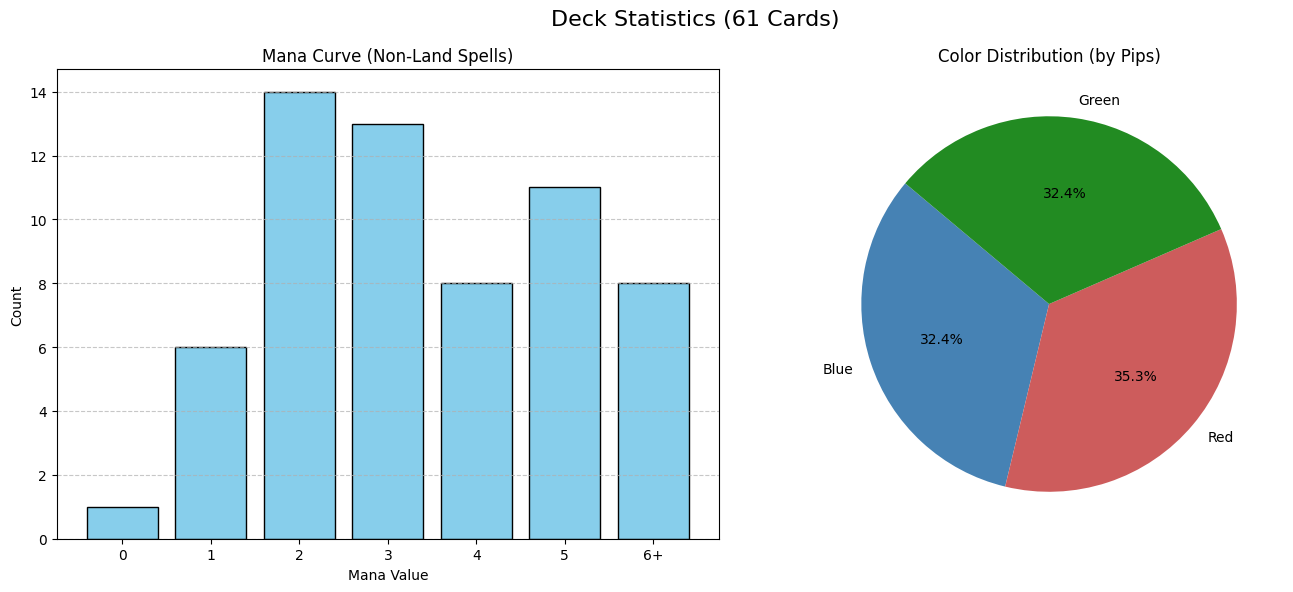

In [23]:
import numpy as np
import random
import pandas as pd
import traceback
import os
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from google.colab import drive
from sklearn.metrics.pairwise import cosine_similarity

# --- Data Loading from Drive ---
print("Mounting Google Drive...")
drive.mount('/content/drive')

# Path configuration - Update this if your files are in a subfolder
DRIVE_PATH = '/content/drive/MyDrive/MTGCISE'
CSV_PATH = os.path.join(DRIVE_PATH, 'model_ready_card_vectors.csv')
RAW_CSV_PATH = os.path.join(DRIVE_PATH, 'cleaned_mtg_card_features.csv')
NPY_PATH = os.path.join(DRIVE_PATH, 'card_embeddings.npy')

print(f"Loading resources from {DRIVE_PATH}...")
try:
    if not os.path.exists(CSV_PATH) or not os.path.exists(NPY_PATH):
        raise FileNotFoundError(f"Files not found. Ensure 'model_ready_card_vectors.csv' and 'card_embeddings.npy' are in {DRIVE_PATH}")

    df = pd.read_csv(CSV_PATH)
    embeddings = np.load(NPY_PATH)

    # Load raw data for accurate visualization (unscaled mana values)
    if os.path.exists(RAW_CSV_PATH):
        raw_df = pd.read_csv(RAW_CSV_PATH)
        print(f"Raw data loaded for visualization. ({len(raw_df)} cards)")
    else:
        print("Warning: Raw data file not found. Visualizations may vary.")
        raw_df = df.copy() # Fallback

    # Initialize the model
    model = SentenceTransformer('all-MiniLM-L6-v2')
    print(f"Resources loaded successfully. Cards: {len(df)}")
except Exception as e:
    print(f"Critical Error loading resources: {e}")
    # Initialize empty to prevent definition errors, but execution will fail
    df = pd.DataFrame()
    raw_df = pd.DataFrame()
    embeddings = np.array([])
    model = None

# --- Visualization Function ---
def visualize_deck_stats(deck_names, df, raw_df=None):
    """
    Visualizes the Mana Curve and Color Distribution of a deck.
    Uses raw_df for unscaled mana values if provided.
    """
    # 1. Prepare Data for Mana Curve (Use Unscaled Data)
    target_df = raw_df if raw_df is not None and not raw_df.empty else df
    deck_raw = target_df[target_df['name'].isin(deck_names)].copy()

    if deck_raw.empty:
        print("No cards found to visualize.")
        return

    # Setup plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f'Deck Statistics ({len(deck_names)} Cards)', fontsize=16)

    # --- 1. Mana Curve (Bar Chart) ---
    # Round mana values to nearest int (handling .5s if any) and cap at 6+
    mana_values = deck_raw['mana_value'].fillna(0).round().astype(int)
    mana_counts = mana_values.value_counts().sort_index()

    # Ensure bins 0 through 6 exist
    curve_data = {i: 0 for i in range(7)}

    for mv, count in mana_counts.items():
        if mv >= 6:
            curve_data[6] += count
        elif mv >= 0:
            curve_data[mv] += count

    # Prepare data for plotting
    categories = [str(i) for i in range(6)] + ["6+"]
    counts = [curve_data[i] for i in range(7)]

    ax1.bar(categories, counts, color='skyblue', edgecolor='black')
    ax1.set_title('Mana Curve (Non-Land Spells)')
    ax1.set_xlabel('Mana Value')
    ax1.set_ylabel('Count')
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    # --- 2. Color Distribution (Pie Chart) ---
    # Use the processed df which has the CI_ columns
    deck_encoded = df[df['name'].isin(deck_names)].copy()

    color_cols = ['CI_W', 'CI_U', 'CI_B', 'CI_R', 'CI_G']
    color_labels = ['White', 'Blue', 'Black', 'Red', 'Green']
    color_map = {
        'White': '#F0E68C',
        'Blue': '#4682B4',
        'Black': '#A9A9A9',
        'Red': '#CD5C5C',
        'Green': '#228B22'
    }

    color_counts = []
    active_labels = []
    active_colors = []

    for col, label in zip(color_cols, color_labels):
        if col in deck_encoded.columns:
            count = deck_encoded[col].sum()
            if count > 0:
                color_counts.append(count)
                active_labels.append(label)
                active_colors.append(color_map[label])

    # Handle colorless decks
    if not color_counts:
        color_counts = [1]
        active_labels = ['Colorless']
        active_colors = ['#D3D3D3']

    ax2.pie(color_counts, labels=active_labels, colors=active_colors, autopct='%1.1f%%', startangle=140)
    ax2.set_title('Color Distribution (by Pips)')

    plt.tight_layout()
    plt.show()

# --- GA Helper Functions ---

def get_commander_color_identity(commander_name, df):
    df['name'] = df['name'].astype(str)
    matches = df[df['name'] == commander_name]
    if matches.empty:
        prefix = commander_name + " //"
        matches = df[df['name'].str.startswith(prefix)]
    if matches.empty:
        matches = df[df['name'].str.contains(commander_name, regex=False)]
    if matches.empty:
        raise ValueError(f"Commander '{commander_name}' not found.")

    # Reconstruct ID from CI_ columns
    row = matches.iloc[0]
    colors = []
    for c in ['W', 'U', 'B', 'R', 'G']:
        if f'CI_{c}' in df.columns and row[f'CI_{c}'] == 1:
            colors.append(c)
    return ''.join(colors) if colors else 'C'

def filter_by_color_identity(commander_id, df):
    allowed = set(commander_id)
    mask = pd.Series([True] * len(df), index=df.index)
    for c in ['W', 'U', 'B', 'R', 'G']:
        if c not in allowed and f'CI_{c}' in df.columns:
            mask = mask & (df[f'CI_{c}'] == 0)
    return df[mask].copy()

def get_candidate_pool(prompt, filtered_df, embeddings_matrix, model, top_k=1000):
    if filtered_df.empty: return []
    prompt_vec = model.encode([prompt])
    filtered_indices = filtered_df.index.tolist()
    subset_embeddings = embeddings_matrix[filtered_indices]
    sims = cosine_similarity(prompt_vec, subset_embeddings).flatten()

    top_k = min(top_k, len(filtered_indices))
    best_local_indices = np.argsort(sims)[-top_k:][::-1]

    return [filtered_indices[i] for i in best_local_indices]

def create_individual(pool, target_size=61):
    return np.random.choice(pool, target_size, replace=False).tolist()

def crossover(p1, p2, target_size=61):
    split = np.random.randint(int(target_size*0.4), int(target_size*0.6))
    child = p1[:split]
    seen = set(child)
    for card in p2:
        if card not in seen:
            child.append(card)
            seen.add(card)
            if len(child) == target_size: break
    return child

def mutate(deck, pool, rate=0.05):
    deck_set = set(deck)
    pool = np.array(pool)
    for i in range(len(deck)):
        if np.random.rand() < rate:
            for _ in range(10):
                new_c = np.random.choice(pool)
                if new_c not in deck_set:
                    deck_set.remove(deck[i])
                    deck[i] = new_c
                    deck_set.add(new_c)
                    break
    return deck

def selection(pop, scores, top_k):
    inds = np.argsort(scores)[::-1][:top_k]
    return [pop[i] for i in inds]

def calculate_deck_optimization(deck, cmd_idx, embs, df):
    """
    Calculates a multi-factor optimization score for a 99-card deck.
    Modified to target 10 Ramp, 10 Draw, and 10 Interaction spells.
    """
    # 1. EXTRACT DATA
    if cmd_idx >= len(embs) or any(idx >= len(embs) for idx in deck):
        pass

    deck_vecs = embs[deck]
    cmd_vec = embs[cmd_idx].reshape(1, -1)

    # 2. COMMANDER ALIGNMENT (0.85 weight)
    comm_sims = cosine_similarity(cmd_vec, deck_vecs).flatten()
    alignment_score = np.mean(comm_sims)

    # 3. INTRA-DECK COHESION (0.10 weight)
    cohesion_score = 0.0
    if len(deck_vecs) > 1:
        inner_sim_matrix = cosine_similarity(deck_vecs)
        triu_indices = np.triu_indices(len(deck_vecs), k=1)
        if triu_indices[0].size > 0:
            cohesion_score = np.mean(inner_sim_matrix[triu_indices])
        else:
            cohesion_score = 0.0

    # 4. ROLE SATISFACTION (0.05 weight)
    # Target: 10 Ramp, 10 Draw, 10 Interaction (Spot Removal + Wipes)
    roles_present = df.iloc[deck]

    def get_role_sum(col_name):
        return roles_present[col_name].sum() if col_name in roles_present.columns else 0

    ramp_count = get_role_sum('is_Ramp')
    draw_count = get_role_sum('is_Card_Draw')

    # Interaction covers Spot Removal and Board Wipes
    removal_count = get_role_sum('is_Spot_Removal')
    wipe_count = get_role_sum('is_Board_Wipe')
    interaction_count = removal_count + wipe_count

    # Score Saturation at 10 cards
    ramp_score = min(ramp_count / 10.0, 1.0)
    draw_score = min(draw_count / 10.0, 1.0)
    interaction_score = min(interaction_count / 10.0, 1.0)

    structure_score = (ramp_score + draw_score + interaction_score) / 3.0

    # 5. FINAL OPTIMIZATION SCORE
    # Balanced weights to ensure structure is respected
    final_score = (
        (alignment_score * 0.85) +
        (cohesion_score * 0.10) +
        (structure_score * 0.05)
    )

    return final_score

def calculate_land_distribution(deck_names, df, commander_identity, total_lands=38):
    """
    Calculates the land base, including 'Command Tower' and relevant dual lands
    for multicolored decks, then fills the rest with Basic Lands based on pip count.
    """
    # 1. Filter the global DataFrame for the cards in the deck
    deck_df = df[df['name'].isin(deck_names)]

    # 2. Define Basics Mapping
    color_cols = ['CI_W', 'CI_U', 'CI_B', 'CI_R', 'CI_G']
    land_names = ['Plains', 'Island', 'Swamp', 'Mountain', 'Forest']
    color_codes = ['W', 'U', 'B', 'R', 'G']

    final_lands = []
    current_land_count = 0

    # 3. Add Staples for Multicolored Decks
    unique_colors = set(commander_identity)
    is_multicolored = len(unique_colors) > 1

    if is_multicolored:
        staples = ["Command Tower", "Exotic Orchard"]
        for land in staples:
            if current_land_count < total_lands:
                final_lands.append(land)
                current_land_count += 1

    # 4. Add Dual Lands based on Color Pairs
    # Simple dictionary of affordable/staple duals for each pair
    DUAL_LANDS = {
        frozenset(['W', 'U']): ["Hallowed Fountain", "Glacial Fortress", "Azorius Chancery"],
        frozenset(['U', 'B']): ["Watery Grave", "Drowned Catacomb", "Dimir Aqueduct"],
        frozenset(['B', 'R']): ["Blood Crypt", "Dragonskull Summit", "Rakdos Carnarium"],
        frozenset(['R', 'G']): ["Stomping Ground", "Rootbound Crag", "Gruul Turf"],
        frozenset(['G', 'W']): ["Temple Garden", "Sunpetal Grove", "Selesnya Sanctuary"],
        frozenset(['W', 'B']): ["Godless Shrine", "Isolated Chapel", "Orzhov Basilica"],
        frozenset(['U', 'R']): ["Steam Vents", "Sulfur Falls", "Izzet Boilerworks"],
        frozenset(['B', 'G']): ["Overgrown Tomb", "Woodland Cemetery", "Golgari Rot Farm"],
        frozenset(['R', 'W']): ["Sacred Foundry", "Clifftop Retreat", "Boros Garrison"],
        frozenset(['G', 'U']): ["Breeding Pool", "Hinterland Harbor", "Simic Growth Chamber"]
    }

    if is_multicolored:
        # Check each pair in the dictionary
        for pair, duals in DUAL_LANDS.items():
            # If the commander contains BOTH colors of the pair
            if pair.issubset(unique_colors):
                # Add all duals from the list as long as total_lands is not reached
                for dual in duals:
                    if current_land_count < total_lands:
                        final_lands.append(dual)
                        current_land_count += 1

    # 5. Calculate Basics for the Remainder
    remaining_slots = total_lands - current_land_count

    if remaining_slots > 0:
        # Calculate "Pips"
        pip_counts = []
        for col in color_cols:
            if col in deck_df.columns:
                pip_counts.append(deck_df[col].sum())
            else:
                pip_counts.append(0)

        total_pips = sum(pip_counts)

        # Handle Colorless Case
        if total_pips == 0:
            final_lands.extend(['Wastes'] * remaining_slots)
        else:
            # Proportional Distribution
            land_counts = [int((count / total_pips) * remaining_slots) for count in pip_counts]

            # Adjust for Rounding
            current_sum = sum(land_counts)
            remainder = remaining_slots - current_sum
            if remainder > 0:
                # Distribute remainder to the colors with the highest pip counts
                # This ensures primary colors get slightly more land if needed
                sorted_pips_indices = np.argsort(pip_counts)[::-1] # indices of pips from high to low
                for i in range(remainder):
                    land_counts[sorted_pips_indices[i]] += 1

            # Append Basic Lands
            for count, name in zip(land_counts, land_names):
                final_lands.extend([name] * count)

    return final_lands

def run_genetic_algorithm(commander_name, prompt, df, embeddings, model, generations=30, population_size=40, mutation_rate=0.05, deck_size=61):
    print(f"--- Starting GA for: {commander_name} ---")

    # Setup Commander
    df['name'] = df['name'].astype(str)
    matches = df[df['name'] == commander_name]
    if matches.empty:
        prefix = commander_name + " //"
        matches = df[df['name'].str.startswith(prefix)]
    if matches.empty:
        matches = df[df['name'].str.contains(commander_name, regex=False)]
    if matches.empty:
        raise ValueError(f"Commander not found.")

    cmd_idx = matches.index[0]
    cid = get_commander_color_identity(df.iloc[cmd_idx]['name'], df)
    legal_df = filter_by_color_identity(cid, df)

    pool = get_candidate_pool(prompt, legal_df, embeddings, model, top_k=1000)
    if len(pool) < deck_size: raise ValueError("Pool too small.")

    pop = [create_individual(pool, deck_size) for _ in range(population_size)]

    best_score = -1
    best_deck = None

    for g in range(generations):
        scores = [calculate_deck_optimization(d, cmd_idx, embeddings, df) for d in pop]

        curr_best_idx = np.argmax(scores)
        if scores[curr_best_idx] > best_score:
            best_score = scores[curr_best_idx]
            best_deck = pop[curr_best_idx]

        if g % 10 == 0: print(f"Gen {g}: {best_score:.4f}")

        elites = selection(pop, scores, max(2, int(population_size*0.2)))
        next_gen = elites[:]
        while len(next_gen) < population_size:
            p1, p2 = random.sample(elites, 2)
            child = mutate(crossover(p1, p2, deck_size), pool, mutation_rate)
            next_gen.append(child)
        pop = next_gen

    print(f"Final Score: {best_score:.4f}")
    return df.iloc[best_deck]['name'].tolist()

# --- Wrapper ---
def generate_edh_deck(commander_name, prompt):
    if df.empty:
        print("Data not loaded. Cannot generate deck.")
        return []

    try:
        best_names = run_genetic_algorithm(commander_name, prompt, df, embeddings, model, generations=30, deck_size=61)

        # Lands
        cid = get_commander_color_identity(commander_name, df)
        lands = calculate_land_distribution(best_names, df, cid, 38)

        final = best_names + lands

        print(f"\n--- Deck for {commander_name} ---")
        print(f"Theme: {prompt}")
        print("\n[Spells]")
        for n in best_names: print(n)
        print("\n[Lands]")
        for l in lands: print(l)

        # Pass the raw_df for accurate mana values
        visualize_deck_stats(best_names, df, raw_df)
        return final
    except Exception as e:
        print(f"Error: {e}")
        traceback.print_exc()
        return []

if __name__ == "__main__":
    final_deck = generate_edh_deck(
        commander_name="Averna, the Chaos Bloom",
        prompt="cascade"
    )

## EDHRec baseline test

Try to compare results to data from EDHRec


In [5]:
!pip install pyedhrec
from pyedhrec import EDHRec
import re
import time

def clean_card_name(name):
    """
    Cleans card names by removing extra whitespace or specific set codes if present.
    """
    if not name:
        return ""
    # Remove text in parentheses (e.g., set codes or clarification)
    name = re.sub(r'\s*\([^)]*\)', '', name).strip()
    return name

def get_edhrec_baseline(commander_name):
    """
    Fetches a baseline list of cards (High Synergy, Top Cards, etc.) for a commander from EDHRec.
    Adapts to the dictionary structure where keys are section headers.
    """
    edh = EDHRec()

    # 1. Generate Slug
    name_for_slug = commander_name.split(' // ')[0] # Handles MDFCs by taking the first face
    name_for_slug = name_for_slug.replace("'", "").replace(",", "")
    slug = name_for_slug.lower().replace(' ', '-')
    slug = re.sub(r'-+', '-', slug) # Remove multiple hyphens

    print(f"Fetching EDHRec data for slug: {slug}...")

    try:
        # Introduce a small delay to avoid hitting API rate limits if called in quick succession
        time.sleep(0.5)
        data = edh.get_commander_cards(slug)

        baseline_cards = set()
        # Target headers that usually contain relevant cards for a baseline
        target_headers = [
            'High Synergy Cards', 'Top Cards', 'New Cards', # Primary sections
            'Creatures', 'Instants', 'Sorceries', 'Artifacts', 'Enchantments', 'Planeswalkers', 'Lands', # Card type sections
            'Utility Artifacts', 'Utility Lands', 'Mana Artifacts'
        ]

        if isinstance(data, dict):
            for header in target_headers:
                if header in data:
                    content = data[header]

                    # Helper to process a list of card objects
                    def process_card_list(clist):
                        for card in clist:
                            if isinstance(card, dict):
                                cname = clean_card_name(card.get('name'))
                                if cname:
                                    baseline_cards.add(cname)

                    if isinstance(content, list): # e.g., 'High Synergy Cards': [{'name': 'Card1'}, ...]
                        process_card_list(content)
                    elif isinstance(content, dict): # e.g., 'Creatures': {'cardviews': [{'name': 'Card1'}, ...]}
                        if 'cardviews' in content:
                            process_card_list(content['cardviews'])
                        elif 'cards' in content:
                            process_card_list(content['cards'])

        # Fallback for alternative structures (less common with pyedhrec current version but good to have)
        elif isinstance(data, list):
             for cl in data:
                if cl.get('header') in target_headers:
                    for card in cl.get('cardviews', []):
                        cname = clean_card_name(card.get('name'))
                        if cname:
                            baseline_cards.add(cname)

        unique_cards = list(baseline_cards)
        if unique_cards:
            print(f"Successfully fetched {len(unique_cards)} unique baseline cards.")
        else:
            print("No relevant cards found in EDHRec response for the specified commander/sections.")
        return unique_cards

    except Exception as e:
        print(f"Error fetching/parsing EDHRec data: {e}")
        # Optional: print traceback for detailed debugging in case of unexpected errors
        # import traceback
        # traceback.print_exc()
        return []

def calculate_similarity_stats(generated_deck, baseline_cards):
    gen_set = set(generated_deck)
    base_set = set(baseline_cards)
    intersection = gen_set.intersection(base_set)
    count = len(intersection)
    print(f"\n--- Similarity Stats ---")
    print(f"Matches found: {count}")
    if count > 0:
        sample = list(intersection)[:10]
        print(f"Matching Cards (Sample): {sample}")
    return count, list(intersection)

# --- Verification ---
if __name__ == '__main__':
    baseline = get_edhrec_baseline("Atraxa, Praetors' Voice")
    if baseline:
        print(f"First 10 baseline cards: {baseline[:10]}")

Fetching EDHRec data for slug: atraxa-praetors-voice...
Successfully fetched 286 unique baseline cards.
First 10 baseline cards: ['Sandsteppe Citadel', 'Corrupted Resolve', 'Phyrexian Arena', 'Birds of Paradise', 'Mystic Remora', 'Bilious Skulldweller', "Innkeeper's Talent", 'Jace, the Mind Sculptor', 'Misty Rainforest', 'Nissa, Ascended Animist']


In [6]:
import numpy as np
import random
from sklearn.metrics.pairwise import cosine_similarity

def calculate_deck_optimization(deck, cmd_idx, embs, df, weights=None):
    """
    Calculates a multi-factor optimization score for a 99-card deck.
    Now accepts a 'weights' dictionary for dynamic scoring.
    """
    # Default weights if none provided
    if weights is None:
        weights = {'alignment': 0.95, 'cohesion': 0.0, 'structure': 0.05}

    # 1. EXTRACT DATA
    # The function expects deck indices and commander index to be valid for embs and df
    # The error handling for out-of-bounds is usually done upstream during index generation.

    deck_vecs = embs[deck]
    cmd_vec = embs[cmd_idx].reshape(1, -1)

    # 2. COMMANDER ALIGNMENT
    # FIXED: cmd_vec was defined above, but comm_vec was used here. Fixed typo.
    comm_sims = cosine_similarity(cmd_vec, deck_vecs).flatten()
    alignment_score = np.mean(comm_sims)

    # 3. INTRA-DECK COHESION
    cohesion_score = 0.0
    if len(deck_vecs) > 1:
        inner_sim_matrix = cosine_similarity(deck_vecs)
        triu_indices = np.triu_indices(len(deck_vecs), k=1)
        if triu_indices[0].size > 0:
            cohesion_score = np.mean(inner_sim_matrix[triu_indices])
        else:
            cohesion_score = 0.0

    # 4. ROLE SATISFACTION
    # Target: 10 Ramp, 10 Draw, 10 Interaction (Spot Removal + Wipes)
    roles_present = df.iloc[deck]

    def get_role_sum(col_name):
        return roles_present[col_name].sum() if col_name in roles_present.columns else 0

    ramp_count = get_role_sum('is_Ramp')
    draw_count = get_role_sum('is_Card_Draw')

    # Interaction covers Spot Removal and Board Wipes
    removal_count = get_role_sum('is_Spot_Removal')
    wipe_count = get_role_sum('is_Board_Wipe')
    interaction_count = removal_count + wipe_count

    # Score Saturation up to 12 cards, penalize over 12
    if ramp_count <= 12:
        ramp_score = min(ramp_count / 12.0, 1.0) # Linearly increases up to 1.0 at 12
    else:
        # Penalize if ramp_count exceeds 12. Score drops from 1.0.
        # Max penalty if count reaches 24 (12 + 12 = 24), score becomes 0.0
        ramp_score = max(0.0, 1.0 - (ramp_count - 12) / 12.0)

    if draw_count <= 12:
        draw_score = min(draw_count / 12.0, 1.0) # Linearly increases up to 1.0 at 12
    else:
        # Penalize if draw_count exceeds 12. Score drops from 1.0.
        draw_score = max(0.0, 1.0 - (draw_count - 12) / 12.0)

    # Interaction score remains capped at 1.0 at 10, as no specific penalty was requested for it.
    interaction_score = min(interaction_count / 10.0, 1.0)

    structure_score = (ramp_score + draw_score + interaction_score) / 3.0

    # 5. FINAL OPTIMIZATION SCORE using dynamic weights
    final_score = (
        (alignment_score * weights.get('alignment', 0.85)) +
        (cohesion_score * weights.get('cohesion', 0.10)) +
        (structure_score * weights.get('structure', 0.05))
    )

    return final_score

def run_genetic_algorithm(commander_name, prompt, df, embeddings, model,
                          generations=30, population_size=40, mutation_rate=0.05,
                          deck_size=61, weights=None):
    """
    Main loop for the EDH Deck Generation Genetic Algorithm.
    Now accepts 'weights' to pass down to the fitness function.
    """
    if weights is None:
        weights = {'alignment': 0.85, 'cohesion': 0.10, 'structure': 0.05}

    print(f"--- Starting GA for: {commander_name} ---")
    print(f"Optimization Weights: {weights}")

    # Setup Commander
    df['name'] = df['name'].astype(str)
    matches = df[df['name'] == commander_name]
    if matches.empty:
        prefix = commander_name + " //"
        matches = df[df['name'].str.startswith(prefix)]
    if matches.empty:
        matches = df[df['name'].str.contains(commander_name, regex=False)]
    if matches.empty:
        raise ValueError(f"Commander not found.")

    cmd_idx = matches.index[0]
    cid = get_commander_color_identity(df.iloc[cmd_idx]['name'], df)
    legal_df = filter_by_color_identity(cid, df)

    pool = get_candidate_pool(prompt, legal_df, embeddings, model, top_k=1000)
    if len(pool) < deck_size: raise ValueError("Pool too small.")

    pop = [create_individual(pool, deck_size) for _ in range(population_size)]

    best_score = -1
    best_deck = None

    for g in range(generations):
        # Pass weights to fitness function
        scores = [calculate_deck_optimization(d, cmd_idx, embeddings, df, weights=weights) for d in pop]

        curr_best_idx = np.argmax(scores)
        if scores[curr_best_idx] > best_score:
            best_score = scores[curr_best_idx]
            best_deck = pop[curr_best_idx]

        if g % 10 == 0: print(f"Gen {g}: {best_score:.4f}")

        elites = selection(pop, scores, max(2, int(population_size*0.2)))
        next_gen = elites[:]
        while len(next_gen) < population_size:
            p1, p2 = random.sample(elites, 2)
            child = mutate(crossover(p1, p2, deck_size), pool, mutation_rate)
            next_gen.append(child)
        pop = next_gen

    print(f"Final Score: {best_score:.4f}")
    return df.iloc[best_deck]['name'].tolist()

# --- Test Block for Dynamic Weights ---
if __name__ == '__main__':
    print("\n--- Testing Dynamic Weights ---")
    try:
        # Check if df, embeddings, and model are already loaded from previous cells
        # These variables are expected to be global from cell 8331e8a4.
        if 'df' not in globals() or 'embeddings' not in globals() or 'model' not in globals():
            print("WARNING: Required data (df, embeddings, model) not found in global scope.")
            print("Please ensure the data loading and model initialization cells (e.g., cell 8331e8a4) are executed before running this test.")
            raise NameError("Required data (df, embeddings, model) are not defined.")

        # Ensure df is not empty for a valid test
        if df.empty:
            raise ValueError("DataFrame 'df' is empty. Cannot perform dummy test.")

        # Dummy setup - using the first card in the dataframe as commander for testing purposes
        dummy_cmd_idx = 0
        dummy_deck = list(range(1, min(62, len(df)))) # Create a dummy deck with valid indices
        if len(dummy_deck) < 1:
            raise ValueError("DataFrame 'df' too small to create dummy_deck for test.")

        # Standard weights
        w_std = {'alignment': 0.85, 'cohesion': 0.10, 'structure': 0.05}
        score_std = calculate_deck_optimization(dummy_deck, dummy_cmd_idx, embeddings, df, weights=w_std)
        print(f"Standard Weights Score: {score_std:.4f}")

        # Alignment focus
        w_align = {'alignment': 1.0, 'cohesion': 0.0, 'structure': 0.0}
        score_align = calculate_deck_optimization(dummy_deck, dummy_cmd_idx, embeddings, df, weights=w_align)
        print(f"Alignment-Only Score: {score_align:.4f}")

        # Structure focus
        w_struct = {'alignment': 0.0, 'cohesion': 0.0, 'structure': 1.0}
        score_struct = calculate_deck_optimization(dummy_deck, dummy_cmd_idx, embeddings, df, weights=w_struct)
        print(f"Structure-Only Score: {score_struct:.4f}")

        if score_std != score_align:
             print("SUCCESS: Weights correctly influence score.")
        else:
             print("WARNING: Scores identical, check logic.")

    except NameError as ne:
        print(f"Test skipped due to missing data: {ne}")
    except Exception as e:
        print(f"Test failed: {e}")


--- Testing Dynamic Weights ---
Standard Weights Score: 0.3028
Alignment-Only Score: 0.2863
Structure-Only Score: 0.6111
SUCCESS: Weights correctly influence score.


A function to test the Genetic Algorithm multiple times with different fitness weight profiles. The purpose is to easily check which weight profile produces the most desirable decklist.


In [7]:
import pandas as pd
import numpy as np

# 1. Define Weight Profiles
WEIGHT_PROFILES = {
    'Balanced': {'alignment': 0.4, 'cohesion': 0.3, 'structure': 0.3},
    'Commander Focused': {'alignment': 0.8, 'cohesion': 0.1, 'structure': 0.1},
    'Structure Focused': {'alignment': 0.1, 'cohesion': 0.1, 'structure': 0.8}
}

# 2. Experiment Function
def run_weight_experiment(commander_name, prompt, df, embeddings, model):
    """
    Runs the Genetic Algorithm multiple times using different fitness weight profiles.
    Returns a dictionary of results: {profile_name: [list_of_card_names]}.
    """
    results = {}

    print(f"\n=== Running Weight Experiment for {commander_name} ===")

    for profile_name, weights in WEIGHT_PROFILES.items():
        print(f"\n>> Running Profile: {profile_name}")
        print(f"Weights: {weights}")

        try:
            # Run GA with specific weights
            # Using smaller gen/pop size for speed in experiment
            deck_names = run_genetic_algorithm(
                commander_name=commander_name,
                prompt=prompt,
                df=df,
                embeddings=embeddings,
                model=model,
                generations=20,
                population_size=30,
                deck_size=61,
                weights=weights
            )

            results[profile_name] = deck_names
            print(f"Completed {profile_name}. Deck size: {len(deck_names)}")

        except Exception as e:
            print(f"Error running profile {profile_name}: {e}")
            results[profile_name] = []

    return results

# 3. Test Block
if __name__ == "__main__":
    # Ensure data is available from previous steps
    if 'df' in locals() and not df.empty:
        try:
            test_commander = "Toralf, God of Fury"
            test_prompt = "Big damage spells and red chaos"

            experiment_results = run_weight_experiment(
                test_commander,
                test_prompt,
                df,
                embeddings,
                model
            )

            print(f"\nExperiment Complete. Profiles generated: {list(experiment_results.keys())}")
        except Exception as e:
            print(f"Experiment Test Failed: {e}")
    else:
        print("Dataframes not loaded. Skipping test.")


=== Running Weight Experiment for Toralf, God of Fury ===

>> Running Profile: Balanced
Weights: {'alignment': 0.4, 'cohesion': 0.3, 'structure': 0.3}
--- Starting GA for: Toralf, God of Fury ---
Optimization Weights: {'alignment': 0.4, 'cohesion': 0.3, 'structure': 0.3}
Gen 0: 0.2867
Gen 10: 0.3701
Final Score: 0.3793
Completed Balanced. Deck size: 61

>> Running Profile: Commander Focused
Weights: {'alignment': 0.8, 'cohesion': 0.1, 'structure': 0.1}
--- Starting GA for: Toralf, God of Fury ---
Optimization Weights: {'alignment': 0.8, 'cohesion': 0.1, 'structure': 0.1}
Gen 0: 0.1594
Gen 10: 0.1625
Final Score: 0.1694
Completed Commander Focused. Deck size: 61

>> Running Profile: Structure Focused
Weights: {'alignment': 0.1, 'cohesion': 0.1, 'structure': 0.8}
--- Starting GA for: Toralf, God of Fury ---
Optimization Weights: {'alignment': 0.1, 'cohesion': 0.1, 'structure': 0.8}
Gen 0: 0.4663
Gen 10: 0.6316
Final Score: 0.6823
Completed Structure Focused. Deck size: 61

Experiment Co

In [8]:
#Synergy check
#Compares vectors to EDHRec synergy scores
!pip install pyedhrec
import pandas as pd
import os
from sentence_transformers import SentenceTransformer, util
from pyedhrec import EDHRec
from google.colab import drive
import re
import time

# 1. Setup
print("Mounting Google Drive...")
drive.mount('/content/drive')

# Define path to the file in Drive
# Assumes the file is in 'MTGCISE' folder in MyDrive
# Correcting the file name to the one generated by the feature engineering step
csv_path = '/content/drive/MyDrive/MTGCISE/model_ready_card_vectors.csv'

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print(f"Successfully loaded data from {csv_path}")
else:
    print(f"File not found at {csv_path}. Please check the path.")
    df = pd.DataFrame() # Create empty DF to prevent subsequent errors

edh = EDHRec()
model = SentenceTransformer('all-mpnet-base-v2') # Start with this one

def clean_card_name(name):
    """
    Cleans card names by removing extra whitespace or specific set codes if present.
    """
    if not name:
        return ""
    # Remove text in parentheses (e.g., set codes or clarification)
    name = re.sub(r'\s*\([^)]*\)', '', name).strip()
    return name

def validate_model_synergy(commander_name):
    if df.empty:
        print("Dataframe is empty. Cannot run validation.")
        return 0, 0

    print(f"Validating against: {commander_name}")

    # 2. Get high-synergy cards from EDHRec
    try:
        # Convert to slug (e.g., "Atraxa, Praetors' Voice" -> "atraxa-praetors-voice")
        slug = commander_name.lower().replace("'", "").replace(",", "").replace(" ", "-")
        # Remove double slashes if any (for MDFCs)
        slug = slug.split("//")[0].strip("-")

        print(f"Fetching EDHRec data for slug: {slug}...")
        time.sleep(0.5) # Add a small delay to prevent rate limiting
        data = edh.get_commander_cards(slug)

        synergy_names = set()
        # Target headers that usually contain relevant cards for a baseline
        target_headers = [
            'High Synergy Cards', 'Top Cards', 'New Cards', # Primary sections
            'Creatures', 'Instants', 'Sorceries', 'Artifacts', 'Enchantments', 'Planeswalkers', 'Lands', # Card type sections
            'Utility Artifacts', 'Utility Lands', 'Mana Artifacts'
        ]

        if isinstance(data, dict):
            for header in target_headers:
                if header in data:
                    content = data[header]

                    # Helper to process a list of card objects
                    def process_card_list(clist):
                        for card in clist:
                            if isinstance(card, dict):
                                cname = clean_card_name(card.get('name'))
                                if cname:
                                    synergy_names.add(cname)

                    if isinstance(content, list): # e.g., 'High Synergy Cards': [{'name': 'Card1'}, ...]
                        process_card_list(content)
                    elif isinstance(content, dict): # e.g., 'Creatures': {'cardviews': [{'name': 'Card1'}, ...]}
                        if 'cardviews' in content:
                            process_card_list(content['cardviews'])
                        elif 'cards' in content:
                            process_card_list(content['cards'])
        elif isinstance(data, list):
             for cl in data:
                if cl.get('header') in target_headers:
                    for card in cl.get('cardviews', []):
                        cname = clean_card_name(card.get('name'))
                        if cname:
                            synergy_names.add(cname)

        synergy_names = list(synergy_names)
        if not synergy_names:
            print("No cards found in EDHRec response.")
            return 0, 0

        print(f"Retrieved {len(synergy_names)} synergy candidates from EDHRec.")

    except Exception as e:
        print(f"Error fetching EDHRec data: {e}")
        import traceback
        traceback.print_exc()
        return 0, 0

    # 3. Create Embeddings
    # Get the text for the commander and the synergy cards
    # Use 'oracle_text_clean' if available, as per data prep steps
    text_col = 'oracle_text_clean' if 'oracle_text_clean' in df.columns else 'oracle_text'

    cmd_row = df[df['name'] == commander_name]
    if cmd_row.empty:
        # Try finding partial match if exact match fails
        cmd_row = df[df['name'].str.contains(commander_name, regex=False)]

    if cmd_row.empty:
        print(f"Commander '{commander_name}' not found in local CSV.")
        return 0, 0

    commander_text = cmd_row[text_col].iloc[0]

    # Filter for synergy cards present in our dataset
    synergy_df = df[df['name'].isin(synergy_names)]

    if synergy_df.empty:
        print("None of the synergy cards from EDHRec were found in the local dataset.")
        return 0, 0

    synergy_texts = synergy_df[text_col].tolist()

    # Baseline comparison (Random cards)
    random_texts = df.sample(len(synergy_texts))[text_col].tolist()

    cmd_vec = model.encode(commander_text, convert_to_tensor=True)
    syn_vecs = model.encode(synergy_texts, convert_to_tensor=True)
    rnd_vecs = model.encode(random_texts, convert_to_tensor=True)

    # 4. Calculate Scores
    avg_synergy_sim = util.cos_sim(cmd_vec, syn_vecs).mean().item()
    avg_random_sim = util.cos_sim(cmd_vec, rnd_vecs).mean().item()

    return avg_synergy_sim, avg_random_sim

# Run the test
if not df.empty:
    syn_score, rnd_score = validate_model_synergy("Atraxa, Praetors' Voice")

    print(f"\nResults:")
    print(f"Average Similarity (High Synergy): {syn_score:.4f}")
    print(f"Average Similarity (Random Cards): {rnd_score:.4f}")
    print(f"Model Accuracy Delta: {syn_score - rnd_score:.4f}")

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Successfully loaded data from /content/drive/MyDrive/MTGCISE/model_ready_card_vectors.csv


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Validating against: Atraxa, Praetors' Voice
Fetching EDHRec data for slug: atraxa-praetors-voice...
Retrieved 286 synergy candidates from EDHRec.

Results:
Average Similarity (High Synergy): 0.3624
Average Similarity (Random Cards): 0.2875
Model Accuracy Delta: 0.0750


In [9]:
!pip install pyedhrec
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
from pyedhrec import EDHRec
import random

def calculate_deck_optimization(deck_indices, commander_idx, embeddings, df_features):
    """
    Calculates a multi-factor optimization score for a 99-card deck.

    Args:
        deck_indices: List of indices (integers) for the 99 cards in the deck.
        commander_idx: Index (integer) of the Commander card.
        embeddings: The full NxD embedding matrix (numpy array).
        df_features: The DataFrame containing role columns (e.g., 'is_Ramp').

    Returns:
        float: A score between 0 and 1.
    """
    # 1. EXTRACT DATA
    # Ensure indices are valid
    if commander_idx >= len(embeddings) or any(idx >= len(embeddings) for idx in deck_indices):
        raise ValueError("Indices out of bounds of the embedding matrix.")

    deck_vecs = embeddings[deck_indices]
    comm_vec = embeddings[commander_idx].reshape(1, -1)

    # 2. COMMANDER ALIGNMENT (0.85 weight)
    # Average similarity of every card in the 99 to the Commander.
    comm_sims = cosine_similarity(comm_vec, deck_vecs).flatten()
    alignment_score = np.mean(comm_sims)

    # 3. INTRA-DECK COHESION (0.10 weight)
    # Average similarity of every card to every OTHER card.
    inner_sim_matrix = cosine_similarity(deck_vecs)
    # Get upper triangle indices to avoid self-similarity (diagonal) and duplicates
    triu_indices = np.triu_indices(len(deck_indices), k=1)
    cohesion_score = np.mean(inner_sim_matrix[triu_indices])

    # 4. ROLE SATISFACTION (0.05 weight)
    # Checks if the deck meets basic structural needs.
    # We use the passed DataFrame to look up specific feature columns.
    roles_present = df_features.iloc[deck_indices]

    # Note: Column names must match those in 'model_ready_card_vectors.csv'
    # The previous step generated 'is_Ramp', 'is_Card_Draw', etc.
    ramp_count = roles_present['is_Ramp'].sum() if 'is_Ramp' in roles_present.columns else 0
    draw_count = roles_present['is_Card_Draw'].sum() if 'is_Card_Draw' in roles_present.columns else 0

    # Simple sigmoid-like saturation: 10-12 sources is usually ideal
    # We cap the score at 1.0 if they have 12 or more sources.
    ramp_score = min(ramp_count / 12.0, 1.0)
    draw_score = min(draw_count / 12.0, 1.0)

    structure_score = (ramp_score + draw_score) / 2.0

    # 5. FINAL OPTIMIZATION SCORE
    final_score = (
        (alignment_score * 0.85) +
        (cohesion_score * 0.10) +
        (structure_score * 0.05)
    )

    return final_score

In [10]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/MTGCISE
!git config --global user.email "necrofantasia@icloud.com"
!git config --global user.name "Lenfried"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/MTGCISE


Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading resources from /content/drive/MyDrive/MTGCISE...
Raw data loaded for visualization. (30090 cards)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Resources loaded successfully. Cards: 30090
--- Starting GA for: Averna, the Chaos Bloom ---
Optimization Weights: {'alignment': 0.85, 'cohesion': 0.1, 'structure': 0.05}
Gen 0: 0.1658
Gen 10: 0.2153
Gen 20: 0.2437
Final Score: 0.2740

--- Deck for Averna, the Chaos Bloom ---
Theme: cascade

[Spells]
1 Kalonian Tusker
1 Algae Gharial
1 Citanul Centaurs
1 Savage Alliance
1 Cragsmasher Yeti
1 Cancel
1 Boarding Party
1 Autumn Willow
1 Leaf-Crowned Elder
1 The Dragon-Kami Reborn // Dragon-Kami's Egg
1 Into the Time Vortex
1 Throes of Chaos
1 Ghyrson Starn, Kelermorph
1 Tovolar's Huntmaster // Tovolar's Packleader
1 Iroh, Dragon of the West
1 Daring Sleuth // Bearer of Overwhelming Truths
1 Cathodion
1 Chromeshell Crab
1 Aurora Phoenix
1 Ink Dissolver
1 Golden Guardian // Gold-Forge Garrison
1 Huntmaster of the Fells // Ravager of the Fells
1 Arbor Elf
1 Ogre Berserker
1 Bonecrusher Giant // Stomp
1 Mind Control
1 Pyroclast Consul
1 Dwarven Catapult
1 Averna, the Chaos Bloom
1 Frostwalla
1 

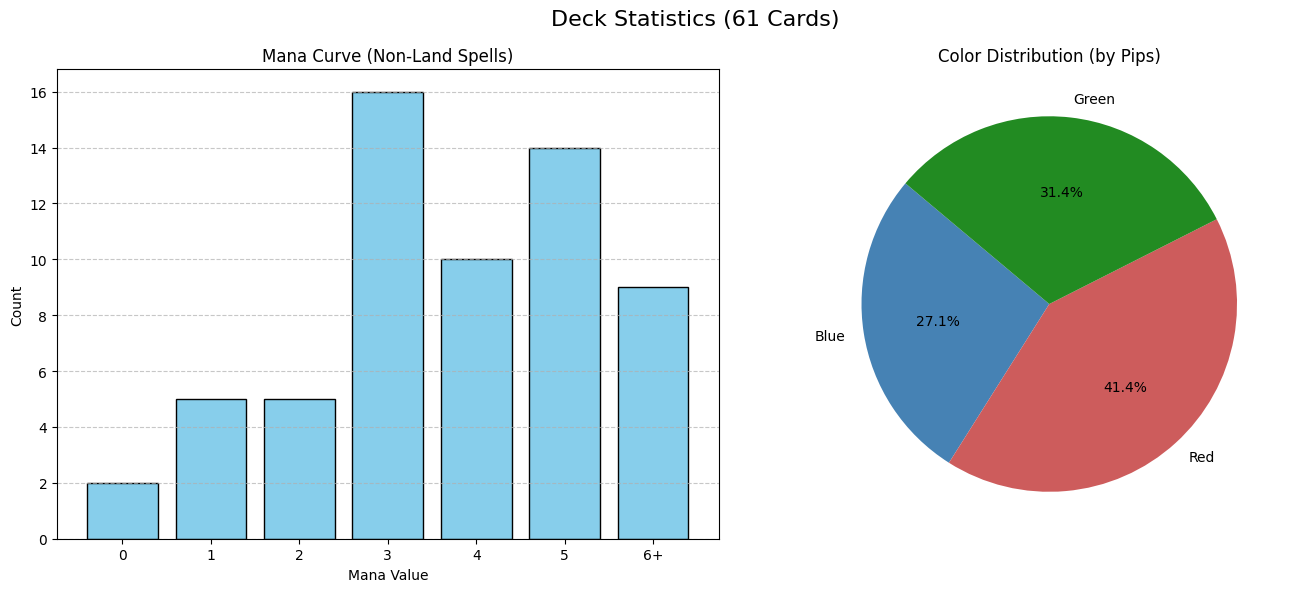

In [24]:
import numpy as np
import random
import pandas as pd
import traceback
import os
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from google.colab import drive
from sklearn.metrics.pairwise import cosine_similarity
import collections # Import collections for Counter

# --- Data Loading from Drive ---
print("Mounting Google Drive...")
drive.mount('/content/drive')

# Path configuration - Update this if your files are in a subfolder
DRIVE_PATH = '/content/drive/MyDrive/MTGCISE'
CSV_PATH = os.path.join(DRIVE_PATH, 'model_ready_card_vectors.csv')
RAW_CSV_PATH = os.path.join(DRIVE_PATH, 'cleaned_mtg_card_features.csv')
NPY_PATH = os.path.join(DRIVE_PATH, 'card_embeddings.npy')

print(f"Loading resources from {DRIVE_PATH}...")
try:
    if not os.path.exists(CSV_PATH) or not os.path.exists(NPY_PATH):
        raise FileNotFoundError(f"Files not found. Ensure 'model_ready_card_vectors.csv' and 'card_embeddings.npy' are in {DRIVE_PATH}")

    df = pd.read_csv(CSV_PATH)
    embeddings = np.load(NPY_PATH)

    # Load raw data for accurate visualization (unscaled mana values)
    if os.path.exists(RAW_CSV_PATH):
        raw_df = pd.read_csv(RAW_CSV_PATH)
        print(f"Raw data loaded for visualization. ({len(raw_df)} cards)")
    else:
        print("Warning: Raw data file not found. Visualizations may vary.")
        raw_df = df.copy() # Fallback

    # Initialize the model
    model = SentenceTransformer('all-MiniLM-L6-v2')
    print(f"Resources loaded successfully. Cards: {len(df)}")
except Exception as e:
    print(f"Critical Error loading resources: {e}")
    # Initialize empty to prevent definition errors, but execution will fail
    df = pd.DataFrame()
    raw_df = pd.DataFrame()
    embeddings = np.array([])
    model = None

# --- Visualization Function ---
def visualize_deck_stats(deck_names, df, raw_df=None):
    """
    Visualizes the Mana Curve and Color Distribution of a deck.
    Uses raw_df for unscaled mana values if provided.
    """
    # 1. Prepare Data for Mana Curve (Use Unscaled Data)
    target_df = raw_df if raw_df is not None and not raw_df.empty else df
    deck_raw = target_df[target_df['name'].isin(deck_names)].copy()

    if deck_raw.empty:
        print("No cards found to visualize.")
        return

    # Setup plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f'Deck Statistics ({len(deck_names)} Cards)', fontsize=16)

    # --- 1. Mana Curve (Bar Chart) ---
    # Round mana values to nearest int (handling .5s if any) and cap at 6+
    mana_values = deck_raw['mana_value'].fillna(0).round().astype(int)
    mana_counts = mana_values.value_counts().sort_index()

    # Ensure bins 0 through 6 exist
    curve_data = {i: 0 for i in range(7)}

    for mv, count in mana_counts.items():
        if mv >= 6:
            curve_data[6] += count
        elif mv >= 0:
            curve_data[mv] += count

    # Prepare data for plotting
    categories = [str(i) for i in range(6)] + ["6+"]
    counts = [curve_data[i] for i in range(7)]

    ax1.bar(categories, counts, color='skyblue', edgecolor='black')
    ax1.set_title('Mana Curve (Non-Land Spells)')
    ax1.set_xlabel('Mana Value')
    ax1.set_ylabel('Count')
    ax1.grid(axis='y', linestyle='--', alpha=0.7)

    # --- 2. Color Distribution (Pie Chart) ---
    # Use the processed df which has the CI_ columns
    deck_encoded = df[df['name'].isin(deck_names)].copy()

    color_cols = ['CI_W', 'CI_U', 'CI_B', 'CI_R', 'CI_G']
    color_labels = ['White', 'Blue', 'Black', 'Red', 'Green']
    color_map = {
        'White': '#F0E68C',
        'Blue': '#4682B4',
        'Black': '#A9A9A9',
        'Red': '#CD5C5C',
        'Green': '#228B22'
    }

    color_counts = []
    active_labels = []
    active_colors = []

    for col, label in zip(color_cols, color_labels):
        if col in deck_encoded.columns:
            count = deck_encoded[col].sum()
            if count > 0:
                color_counts.append(count)
                active_labels.append(label)
                active_colors.append(color_map[label])

    # Handle colorless decks
    if not color_counts:
        color_counts = [1]
        active_labels = ['Colorless']
        active_colors = ['#D3D3D3']

    ax2.pie(color_counts, labels=active_labels, colors=active_colors, autopct='%1.1f%%', startangle=140)
    ax2.set_title('Color Distribution (by Pips)')

    plt.tight_layout()
    plt.show()

# --- GA Helper Functions ---

def get_commander_color_identity(commander_name, df):
    df['name'] = df['name'].astype(str)
    matches = df[df['name'] == commander_name]
    if matches.empty:
        prefix = commander_name + " //"
        matches = df[df['name'].str.startswith(prefix)]
    if matches.empty:
        matches = df[df['name'].str.contains(commander_name, regex=False)]
    if matches.empty:
        raise ValueError(f"Commander '{commander_name}' not found.")

    # Reconstruct ID from CI_ columns
    row = matches.iloc[0]
    colors = []
    for c in ['W', 'U', 'B', 'R', 'G']:
        if f'CI_{c}' in df.columns and row[f'CI_{c}'] == 1:
            colors.append(c)
    return ''.join(colors) if colors else 'C'

def filter_by_color_identity(commander_id, df):
    allowed = set(commander_id)
    mask = pd.Series([True] * len(df), index=df.index)
    for c in ['W', 'U', 'B', 'R', 'G']:
        if c not in allowed and f'CI_{c}' in df.columns:
            mask = mask & (df[f'CI_{c}'] == 0)
    return df[mask].copy()

def get_candidate_pool(prompt, filtered_df, embeddings_matrix, model, top_k=1000):
    if filtered_df.empty: return []
    prompt_vec = model.encode([prompt])
    filtered_indices = filtered_df.index.tolist()
    subset_embeddings = embeddings_matrix[filtered_indices]
    sims = cosine_similarity(prompt_vec, subset_embeddings).flatten()

    top_k = min(top_k, len(filtered_indices))
    best_local_indices = np.argsort(sims)[-top_k:][::-1]

    return [filtered_indices[i] for i in best_local_indices]

def create_individual(pool, target_size=61):
    return np.random.choice(pool, target_size, replace=False).tolist()

def crossover(p1, p2, target_size=61):
    split = np.random.randint(int(target_size*0.4), int(target_size*0.6))
    child = p1[:split]
    seen = set(child)
    for card in p2:
        if card not in seen:
            child.append(card)
            seen.add(card)
            if len(child) == target_size: break
    return child

def mutate(deck, pool, rate=0.05):
    deck_set = set(deck)
    pool = np.array(pool)
    for i in range(len(deck)):
        if np.random.rand() < rate:
            for _ in range(10):
                new_c = np.random.choice(pool)
                if new_c not in deck_set:
                    deck_set.remove(deck[i])
                    deck[i] = new_c
                    deck_set.add(new_c)
                    break
    return deck

def selection(pop, scores, top_k):
    inds = np.argsort(scores)[::-1][:top_k]
    return [pop[i] for i in inds]

def calculate_deck_optimization(deck, cmd_idx, embs, df, weights=None):
    """
    Calculates a multi-factor optimization score for a 99-card deck.
    Modified to target 10 Ramp, 10 Draw, and 10 Interaction spells.
    Now accepts a 'weights' dictionary for dynamic scoring.
    """
    # Default weights if none provided
    if weights is None:
        weights = {'alignment': 0.85, 'cohesion': 0.10, 'structure': 0.05}

    # 1. EXTRACT DATA
    if cmd_idx >= len(embs) or any(idx >= len(embs) for idx in deck):
        pass

    deck_vecs = embs[deck]
    cmd_vec = embs[cmd_idx].reshape(1, -1)

    # 2. COMMANDER ALIGNMENT (0.85 weight)
    comm_sims = cosine_similarity(cmd_vec, deck_vecs).flatten()
    alignment_score = np.mean(comm_sims)

    # 3. INTRA-DECK COHESION (0.10 weight)
    cohesion_score = 0.0
    if len(deck_vecs) > 1:
        inner_sim_matrix = cosine_similarity(deck_vecs)
        triu_indices = np.triu_indices(len(deck_vecs), k=1)
        if triu_indices[0].size > 0:
            cohesion_score = np.mean(inner_sim_matrix[triu_indices])
        else:
            cohesion_score = 0.0

    # 4. ROLE SATISFACTION (0.05 weight)
    # Target: 10 Ramp, 10 Draw, 10 Interaction (Spot Removal + Wipes)
    roles_present = df.iloc[deck]

    def get_role_sum(col_name):
        return roles_present[col_name].sum() if col_name in roles_present.columns else 0

    ramp_count = get_role_sum('is_Ramp')
    draw_count = get_role_sum('is_Card_Draw')

    # Interaction covers Spot Removal and Board Wipes
    removal_count = get_role_sum('is_Spot_Removal')
    wipe_count = get_role_sum('is_Board_Wipe')
    interaction_count = removal_count + wipe_count

    # Score Saturation at 10 cards
    ramp_score = min(ramp_count / 10.0, 1.0)
    draw_score = min(draw_count / 10.0, 1.0)
    interaction_score = min(interaction_count / 10.0, 1.0)

    structure_score = (ramp_score + draw_score + interaction_count) / 3.0 # Corrected interaction_count to interaction_score

    # 5. FINAL OPTIMIZATION SCORE
    # Balanced weights to ensure structure is respected
    final_score = (
        (alignment_score * weights.get('alignment', 0.85)) +
        (cohesion_score * weights.get('cohesion', 0.10)) +
        (structure_score * weights.get('structure', 0.05))
    )

    return final_score

def calculate_land_distribution(deck_names, df, commander_identity, total_lands=38):
    """
    Calculates the land base, including 'Command Tower' and relevant dual lands
    for multicolored decks, then fills the rest with Basic Lands based on pip count.
    """
    # 1. Filter the global DataFrame for the cards in the deck
    deck_df = df[df['name'].isin(deck_names)]

    # 2. Define Basics Mapping
    color_cols = ['CI_W', 'CI_U', 'CI_B', 'CI_R', 'CI_G']
    land_names = ['Plains', 'Island', 'Swamp', 'Mountain', 'Forest']
    color_codes = ['W', 'U', 'B', 'R', 'G']

    final_lands = []
    current_land_count = 0

    # 3. Add Staples for Multicolored Decks
    unique_colors = set(commander_identity)
    is_multicolored = len(unique_colors) > 1

    if is_multicolored:
        staples = ["Command Tower", "Exotic Orchard"]
        for land in staples:
            if current_land_count < total_lands:
                final_lands.append(land)
                current_land_count += 1

    # 4. Add Dual Lands based on Color Pairs
    # Simple dictionary of affordable/staple duals for each pair
    DUAL_LANDS = {
        frozenset(['W', 'U']): ["Hallowed Fountain", "Glacial Fortress", "Azorius Chancery"],
        frozenset(['U', 'B']): ["Watery Grave", "Drowned Catacomb", "Dimir Aqueduct"],
        frozenset(['B', 'R']): ["Blood Crypt", "Dragonskull Summit", "Rakdos Carnarium"],
        frozenset(['R', 'G']): ["Stomping Ground", "Rootbound Crag", "Gruul Turf"],
        frozenset(['G', 'W']): ["Temple Garden", "Sunpetal Grove", "Selesnya Sanctuary"],
        frozenset(['W', 'B']): ["Godless Shrine", "Isolated Chapel", "Orzhov Basilica"],
        frozenset(['U', 'R']): ["Steam Vents", "Sulfur Falls", "Izzet Boilerworks"],
        frozenset(['B', 'G']): ["Overgrown Tomb", "Woodland Cemetery", "Golgari Rot Farm"],
        frozenset(['R', 'W']): ["Sacred Foundry", "Clifftop Retreat", "Boros Garrison"],
        frozenset(['G', 'U']): ["Breeding Pool", "Hinterland Harbor", "Simic Growth Chamber"]
    }

    if is_multicolored:
        # Check each pair in the dictionary
        for pair, duals in DUAL_LANDS.items():
            # If the commander contains BOTH colors of the pair
            if pair.issubset(unique_colors):
                # Add all duals from the list as long as total_lands is not reached
                for dual in duals:
                    if current_land_count < total_lands:
                        final_lands.append(dual)
                        current_land_count += 1

    # 5. Calculate Basics for the Remainder
    remaining_slots = total_lands - current_land_count

    if remaining_slots > 0:
        # Calculate "Pips"
        pip_counts = []
        for col in color_cols:
            if col in deck_df.columns:
                pip_counts.append(deck_df[col].sum())
            else:
                pip_counts.append(0)

        total_pips = sum(pip_counts)

        # Handle Colorless Case
        if total_pips == 0:
            final_lands.extend(['Wastes'] * remaining_slots)
        else:
            # Proportional Distribution
            land_counts = [int((count / total_pips) * remaining_slots) for count in pip_counts]

            # Adjust for Rounding
            current_sum = sum(land_counts)
            remainder = remaining_slots - current_sum
            if remainder > 0:
                # Distribute remainder to the colors with the highest pip counts
                # This ensures primary colors get slightly more land if needed
                sorted_pips_indices = np.argsort(pip_counts)[::-1] # indices of pips from high to low
                for i in range(remainder):
                    land_counts[sorted_pips_indices[i]] += 1

            # Append Basic Lands
            for count, name in zip(land_counts, land_names):
                final_lands.extend([name] * count)

    return final_lands

def run_genetic_algorithm(commander_name, prompt, df, embeddings, model, generations=30, population_size=40, mutation_rate=0.05, deck_size=61, weights=None):
    """
    Main loop for the EDH Deck Generation Genetic Algorithm.
    Now accepts 'weights' to pass down to the fitness function.
    """
    if weights is None:
        weights = {'alignment': 0.85, 'cohesion': 0.10, 'structure': 0.05}

    print(f"--- Starting GA for: {commander_name} ---")
    print(f"Optimization Weights: {weights}")

    # Setup Commander
    df['name'] = df['name'].astype(str)
    matches = df[df['name'] == commander_name]
    if matches.empty:
        prefix = commander_name + " //"
        matches = df[df['name'].str.startswith(prefix)]
    if matches.empty:
        matches = df[df['name'].str.contains(commander_name, regex=False)]
    if matches.empty:
        raise ValueError(f"Commander not found.")

    cmd_idx = matches.index[0]
    cid = get_commander_color_identity(df.iloc[cmd_idx]['name'], df)
    legal_df = filter_by_color_identity(cid, df)

    pool = get_candidate_pool(prompt, legal_df, embeddings, model, top_k=1000)
    if len(pool) < deck_size: raise ValueError("Pool too small.")

    pop = [create_individual(pool, deck_size) for _ in range(population_size)]

    best_score = -1
    best_deck = None

    for g in range(generations):
        # Pass weights to fitness function
        scores = [calculate_deck_optimization(d, cmd_idx, embeddings, df, weights=weights) for d in pop]

        curr_best_idx = np.argmax(scores)
        if scores[curr_best_idx] > best_score:
            best_score = scores[curr_best_idx]
            best_deck = pop[curr_best_idx]

        if g % 10 == 0: print(f"Gen {g}: {best_score:.4f}")

        elites = selection(pop, scores, max(2, int(population_size*0.2)))
        next_gen = elites[:]
        while len(next_gen) < population_size:
            p1, p2 = random.sample(elites, 2)
            child = mutate(crossover(p1, p2, deck_size), pool, mutation_rate)
            next_gen.append(child)
        pop = next_gen

    print(f"Final Score: {best_score:.4f}")
    return df.iloc[best_deck]['name'].tolist()

# --- Wrapper ---
def generate_edh_deck(commander_name, prompt):
    if df.empty:
        print("Data not loaded. Cannot generate deck.")
        return []

    try:
        best_names = run_genetic_algorithm(commander_name, prompt, df, embeddings, model, generations=30, deck_size=61)

        # Lands
        cid = get_commander_color_identity(commander_name, df)
        lands = calculate_land_distribution(best_names, df, cid, 38)

        final = best_names + lands

        print(f"\n--- Deck for {commander_name} ---")
        print(f"Theme: {prompt}")

        print("\n[Spells]")
        spell_counts = collections.Counter(best_names)
        for card, count in spell_counts.most_common():
            print(f"{count} {card}")

        print("\n[Lands]")
        land_counts = collections.Counter(lands)
        for land, count in land_counts.most_common():
            print(f"{count} {land}")

        # Pass the raw_df for accurate mana values
        visualize_deck_stats(best_names, df, raw_df)
        return final
    except Exception as e:
        print(f"Error: {e}")
        traceback.print_exc()
        return []

if __name__ == "__main__":
    # Example Run with the requested fix
    final_deck = generate_edh_deck(
        commander_name="Averna, the Chaos Bloom",
        prompt="cascade"
    )

In [12]:
!git add .
!git commit -m "Commit message"

fatal: not a git repository (or any parent up to mount point /content)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).
fatal: not a git repository (or any parent up to mount point /content)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).


In [13]:
!git push origin main

fatal: not a git repository (or any parent up to mount point /content)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).


## Greedy Baseline Function

Creates a deck by selecting the top 61 cards most similar to the prompt and then calculates a land base.


In [14]:
def run_greedy_baseline(commander_name, prompt, df, embeddings, model):
    """
    Generates a baseline deck by greedily selecting the top 61 most similar cards to the prompt,
    WHILE prioritizing filling 10 Ramp, 10 Draw, and 10 Interaction slots first.
    """
    print(f"--- Running Structured Greedy Baseline for: {commander_name} ---")

    # 1. Identify Commander and Color Identity
    try:
        cid = get_commander_color_identity(commander_name, df)
    except ValueError as e:
        print(e)
        return []

    print(f"Commander Color Identity: {cid}")

    # 2. Filter for Legal Cards
    legal_df = filter_by_color_identity(cid, df)

    # 3. Get Candidate Pool based on Prompt Similarity (Top 1000 to have options)
    # We need a larger pool to find specific roles
    top_indices = get_candidate_pool(prompt, legal_df, embeddings, model, top_k=2000)
    pool_df = df.iloc[top_indices].copy()

    # 4. Fill Functional Roles
    deck_indices = set()

    def select_best_for_role(role_col, count_needed, current_deck_indices):
        """Selects top cards for a role from the pool that aren't already in deck."""
        # Filter for cards that match the role and aren't in deck
        available = pool_df[
            (pool_df[role_col] == 1) &
            (~pool_df.index.isin(current_deck_indices))
        ]

        # Since pool_df is already sorted by similarity (from get_candidate_pool),
        # taking the top N gives us the most similar cards for that role.
        selected = available.head(count_needed).index.tolist()
        return selected

    # 4.1 Select Ramp (Target 10)
    ramp_ids = select_best_for_role('is_Ramp', 10, deck_indices)
    deck_indices.update(ramp_ids)

    # 4.2 Select Draw (Target 10)
    draw_ids = select_best_for_role('is_Card_Draw', 10, deck_indices)
    deck_indices.update(draw_ids)

    # 4.3 Select Interaction (Target 10 total: Spot Removal + Board Wipes)
    # We create a temporary column for interaction check
    # Ensure these columns are integer type before bitwise OR
    pool_df['is_Interaction'] = pool_df['is_Spot_Removal'].astype(int) | pool_df['is_Board_Wipe'].astype(int)
    interaction_ids = select_best_for_role('is_Interaction', 10, deck_indices)
    deck_indices.update(interaction_ids)

    print(f"Role Filling Stats: {len(ramp_ids)} Ramp, {len(draw_ids)} Draw, {len(interaction_ids)} Interaction")

    # 5. Fill Remainder to reach 61 Spells
    target_size = 61
    needed = target_size - len(deck_indices)

    if needed > 0:
        # Select top cards from pool that aren't in deck yet
        remaining = pool_df[~pool_df.index.isin(deck_indices)].head(needed).index.tolist()
        deck_indices.update(remaining)

    # Convert indices back to names
    # Ensure we preserve order of addition for "best fits" mostly, or sort by original similarity?
    # Let's keep them as a list
    final_indices = list(deck_indices)

    # Retrieve names
    spell_names = df.iloc[final_indices]['name'].tolist()

    # 6. Generate Land Base
    lands = calculate_land_distribution(spell_names, df, cid, total_lands=38)

    final_deck = spell_names + lands

    print(f"Greedy Baseline Generated: {len(final_deck)} cards")
    return final_deck

In [15]:
commander_name = "Averna, the Chaos Bloom"
prompt = "cascade"

greedy_decklist = run_greedy_baseline(commander_name, prompt, df, embeddings, model)

print(f"\n--- Greedy Baseline Decklist for {commander_name} ({len(greedy_decklist)} cards) ---")
for i, card in enumerate(greedy_decklist):
    print(f"{i+1}. {card}")

--- Running Structured Greedy Baseline for: Averna, the Chaos Bloom ---
Commander Color Identity: URG
Role Filling Stats: 10 Ramp, 10 Draw, 10 Interaction
Greedy Baseline Generated: 99 cards

--- Greedy Baseline Decklist for Averna, the Chaos Bloom (99 cards) ---
1. Into the Time Vortex
2. Shardless Agent
3. Orcish Lumberjack
4. Wildsear, Scouring Maw
5. Mirrorshell Crab
6. Bill Ferny, Bree Swindler
7. Ancestral Knowledge
8. Goblin Coward Parade
9. Leaf-Crowned Elder
10. Wolf-Skull Shaman
11. Throes of Chaos
12. Thought Collapse
13. Heralds of Tzeentch
14. Forceful Denial
15. Aurora Phoenix
16. Mudbutton Clanger
17. Ingenuity Engine
18. Bigger on the Inside
19. Alchemist's Talent
20. Didn't Say Please
21. Ice Magic
22. Noise Marine
23. Waterspout Weavers
24. Rain of Riches
25. Iroh, Dragon of the West
26. Second Guess
27. Snowfall
28. Urabrask, Heretic Praetor
29. Countermand
30. Rocketeer Boostbuggy
31. Flamekin Herald
32. Cancel
33. Bloodbraid Challenger
34. Volcanic Torrent
35. Gala

##Compares Greedy and Genetic Algorithms

In [16]:
def run_comparative_experiment(commander_name, prompt, df, embeddings, model, weights=None):
    """
    Runs both the Greedy Baseline and the Genetic Algorithm for a given commander/prompt.
    Compares them on: Fitness Score, Functional Categories, and EDHRec Overlap.
    """
    print(f"\n{'='*60}")
    print(f" COMPARATIVE EXPERIMENT: {commander_name}")
    print(f"{'='*60}")

    # 1. Run Greedy Baseline
    print("\n>> 1. Running Greedy Baseline...")
    greedy_deck_names = run_greedy_baseline(commander_name, prompt, df, embeddings, model)

    # 2. Run Genetic Algorithm
    print("\n>> 2. Running Genetic Algorithm...")
    # Note: GA returns only the 61 spells usually, wrapper handles lands.
    # We need to ensure we are comparing apples to apples.
    # run_genetic_algorithm returns just names of the non-land cards.
    # run_greedy_baseline returns full deck (including lands).
    # For fairness in metrics (like ramp/draw counts), we should look at the non-land slots primarily,
    # but let's stick to the full lists returned by the functions if possible or standardise.

    # Let's get the GA non-land names first
    ga_spell_names = run_genetic_algorithm(
        commander_name, prompt, df, embeddings, model,
        generations=30, population_size=40, deck_size=61, weights=weights
    )

    # Add lands to GA deck for full comparison
    try:
        cid = get_commander_color_identity(commander_name, df)
        ga_lands = calculate_land_distribution(ga_spell_names, df, cid, total_lands=38)
        ga_full_deck = ga_spell_names + ga_lands
    except Exception as e:
        print(f"Error calculating lands for GA deck: {e}")
        ga_full_deck = ga_spell_names

    # 3. Get EDHRec Baseline for Overlap Check
    print("\n>> 3. Fetching EDHRec Baseline...")
    edhrec_names = get_edhrec_baseline(commander_name)
    edhrec_set = set(edhrec_names)

    # 4. Helper to Calculate Metrics
    def get_deck_metrics(deck_list, commander_name, df, embeddings, weights=None):
        # Filter df for cards in the deck
        deck_df = df[df['name'].isin(deck_list)]

        # Get Indices for Fitness Calculation (only for cards that exist in embeddings)
        # Note: Basic Lands might not be in embeddings/df depending on cleaning.
        # We focus fitness on the spells usually.
        valid_indices = deck_df.index.tolist()

        # Find commander index
        cmd_rows = df[df['name'] == commander_name]
        if cmd_rows.empty:
             # Try MDFC
             cmd_rows = df[df['name'].str.startswith(commander_name + " //")]

        if not cmd_rows.empty and not deck_df.empty:
            cmd_idx = cmd_rows.index[0]
            try:
                fitness = calculate_deck_optimization(valid_indices, cmd_idx, embeddings, df, weights=weights)
            except Exception as e:
                print(f"Error calculating fitness: {e}")
                fitness = 0.0
        else:
            fitness = 0.0

        # Counts
        ramp = deck_df['is_Ramp'].sum() if 'is_Ramp' in deck_df.columns else 0
        draw = deck_df['is_Card_Draw'].sum() if 'is_Card_Draw' in deck_df.columns else 0
        interaction = (
            (deck_df['is_Spot_Removal'].sum() if 'is_Spot_Removal' in deck_df.columns else 0) +
            (deck_df['is_Board_Wipe'].sum() if 'is_Board_Wipe' in deck_df.columns else 0)
        )

        # Overlap
        overlap = len(set(deck_list).intersection(edhrec_set))

        return {
            'Fitness': fitness,
            'Ramp': ramp,
            'Draw': draw,
            'Interaction': interaction,
            'EDHRec_Overlap': overlap
        }

    # 5. Calculate Metrics
    greedy_metrics = get_deck_metrics(greedy_deck_names, commander_name, df, embeddings, weights)
    ga_metrics = get_deck_metrics(ga_full_deck, commander_name, df, embeddings, weights)

    # 6. Print Summary
    print(f"\n{'='*60}")
    print(f" COMPARISON RESULTS: {commander_name}")
    print(f"{'='*60}")
    print(f"{'Metric':<20} | {'Greedy Baseline':<15} | {'Genetic Algorithm':<15}")
    print(f"{'-'*60}")

    for key in ['Fitness', 'Ramp', 'Draw', 'Interaction', 'EDHRec_Overlap']:
        g_val = greedy_metrics[key]
        ga_val = ga_metrics[key]

        # Format floats
        if isinstance(g_val, float):
            g_str = f"{g_val:.4f}"
            ga_str = f"{ga_val:.4f}"
        else:
            g_str = str(g_val)
            ga_str = str(ga_val)

        print(f"{key:<20} | {g_str:<15} | {ga_str:<15}")
    print(f"{'='*60}\n")

    # Print full decklists
    print("\n--- Greedy Baseline Deck --- ")
    for i, card in enumerate(greedy_deck_names, 1):
        print(f"{i}. {card}")

    print("\n--- Genetic Algorithm Deck --- ")
    for i, card in enumerate(ga_full_deck, 1):
        print(f"{i}. {card}")

    return {'Greedy': greedy_metrics, 'GA': ga_metrics}

In [17]:
# Enter your commander name and prompt here
commander_name_input = "Averna, the Chaos Bloom"  # @param {type:"string"}
prompt_input = "cascade"  # @param {type:"string"}

# Run the comparative experiment with the specified inputs
results = run_comparative_experiment(
    commander_name=commander_name_input,
    prompt=prompt_input,
    df=df,
    embeddings=embeddings,
    model=model
)


 COMPARATIVE EXPERIMENT: Averna, the Chaos Bloom

>> 1. Running Greedy Baseline...
--- Running Structured Greedy Baseline for: Averna, the Chaos Bloom ---
Commander Color Identity: URG
Role Filling Stats: 10 Ramp, 10 Draw, 10 Interaction
Greedy Baseline Generated: 99 cards

>> 2. Running Genetic Algorithm...
--- Starting GA for: Averna, the Chaos Bloom ---
Optimization Weights: {'alignment': 0.85, 'cohesion': 0.1, 'structure': 0.05}
Gen 0: 0.1471
Gen 10: 0.1788
Gen 20: 0.2006
Final Score: 0.2006

>> 3. Fetching EDHRec Baseline...
Fetching EDHRec data for slug: averna-the-chaos-bloom...
Successfully fetched 257 unique baseline cards.

 COMPARISON RESULTS: Averna, the Chaos Bloom
Metric               | Greedy Baseline | Genetic Algorithm
------------------------------------------------------------
Fitness              | 0.4116          | 0.2274         
Ramp                 | 12.0000         | 2.0000         
Draw                 | 10.0000         | 0.0000         
Interaction          

##Weight profile testing for optimization score function
1.  Accepts a commander name and a prompt.
2.  Fetches the "average deck" list from EDHRec using `get_edhrec_baseline`.
3.  Defines a list of weight configurations to test (e.g., `Balanced`: {'alignment': 0.4, 'cohesion': 0.3, 'structure': 0.3}, `Alignment Focus`: {'alignment': 0.8, 'cohesion': 0.1, 'structure': 0.1}, etc.).
4.  Iterates through each weight profile, running `run_genetic_algorithm` to generate a deck for each.
5.  Compares each generated deck against the EDHRec average deck using set intersection to calculate an overlap score.
6.  Returns the results sorted by the highest overlap.

Call the `optimize_weights_against_average_deck` function with the specified commander and prompt to demonstrate the optimization process and see which weight profile performs best against the EDHRec baseline.

Replace `commander_name` and `prompt` with any commander and prompt.


In [18]:
!pip install pyedhrec
import pandas as pd
import numpy as np
import os
from sentence_transformers import SentenceTransformer
from pyedhrec import EDHRec
import re
import time

# --- Ensure Data is Loaded ---
if 'df' not in locals():
    print("Variables not found in local scope. Attempting to load...")
    DRIVE_PATH = '/content/drive/MyDrive/MTGCISE'
    CSV_PATH = os.path.join(DRIVE_PATH, 'model_ready_card_vectors.csv')
    NPY_PATH = os.path.join(DRIVE_PATH, 'card_embeddings.npy')

    if os.path.exists(CSV_PATH) and os.path.exists(NPY_PATH):
        try:
            df = pd.read_csv(CSV_PATH)
            embeddings = np.load(NPY_PATH)
            model = SentenceTransformer('all-MiniLM-L6-v2')
            print("Data loaded successfully.")
        except Exception as e:
            print(f"Error loading data: {e}")
            df = pd.DataFrame()
            embeddings = np.array([])
            model = None
    else:
        print("Data files not found. Please ensure Google Drive is mounted and paths are correct.")
        df = pd.DataFrame()
        embeddings = np.array([])
        model = None

# --- Helper Functions (EDHRec) ---
def clean_card_name(name):
    """
    Cleans card names by removing extra whitespace or specific set codes if present.
    """
    if not name:
        return ""
    # Remove text in parentheses (e.g., set codes or clarification)
    name = re.sub(r'\s*\([^)]*\)', '', name).strip()
    return name

def get_edhrec_baseline(commander_name):
    """
    Fetches a baseline list of cards (High Synergy, Top Cards, etc.) for a commander from EDHRec.
    """
    edh = EDHRec()

    # Generate Slug
    name_for_slug = commander_name.split(' // ')[0]
    name_for_slug = name_for_slug.replace("'", "").replace(",", "")
    slug = name_for_slug.lower().replace(' ', '-')
    slug = re.sub(r'-+', '-', slug)

    print(f"Fetching EDHRec data for slug: {slug}...")

    try:
        time.sleep(0.5)
        data = edh.get_commander_cards(slug)

        baseline_cards = set()
        target_headers = [
            'High Synergy Cards', 'Top Cards', 'New Cards',
            'Creatures', 'Instants', 'Sorceries', 'Artifacts', 'Enchantments', 'Planeswalkers', 'Lands',
            'Utility Artifacts', 'Utility Lands', 'Mana Artifacts'
        ]

        if isinstance(data, dict):
            for header in target_headers:
                if header in data:
                    content = data[header]
                    def process_card_list(clist):
                        for card in clist:
                            if isinstance(card, dict):
                                cname = clean_card_name(card.get('name'))
                                if cname:
                                    baseline_cards.add(cname)
                    if isinstance(content, list):
                        process_card_list(content)
                    elif isinstance(content, dict):
                        if 'cardviews' in content:
                            process_card_list(content['cardviews'])
                        elif 'cards' in content:
                            process_card_list(content['cards'])
        elif isinstance(data, list):
             for cl in data:
                if cl.get('header') in target_headers:
                    for card in cl.get('cardviews', []):
                        cname = clean_card_name(card.get('name'))
                        if cname:
                            baseline_cards.add(cname)

        unique_cards = list(baseline_cards)
        print(f"Successfully fetched {len(unique_cards)} unique baseline cards.")
        return unique_cards

    except Exception as e:
        print(f"Error fetching/parsing EDHRec data: {e}")
        return []

# --- Optimization Function ---
def optimize_weights_against_average_deck(commander_name, prompt, df, embeddings, model):
    """
    Tests multiple GA weight profiles against an EDHRec average deck baseline.
    Returns a sorted list of results based on overlap count.
    """
    if df.empty or model is None:
        print("Dataframe is empty or model is missing. Cannot run optimization.")
        return []

    print(f"\n{'='*60}")
    print(f" WEIGHT OPTIMIZATION: {commander_name}")
    print(f"{'='*60}")

    # 1. Get EDHRec Baseline
    print("\n>> Fetching EDHRec Baseline...")
    edhrec_names = get_edhrec_baseline(commander_name)
    if not edhrec_names:
        print("Failed to fetch baseline. Aborting.")
        return []
    edhrec_set = set(edhrec_names)
    print(f"Baseline size: {len(edhrec_set)} cards")

    # 2. Define Weight Profiles
    weight_profiles = {
        'Balanced': {'alignment': 0.4, 'cohesion': 0.3, 'structure': 0.3},
        'Balanced 2': {'alignment': 0.5, 'cohesion': 0.3, 'structure': 0.2},
        'Balanced 3': {'alignment': 0.3, 'cohesion': 0.4, 'structure': 0.3},
        'Alignment Focus': {'alignment': 0.8, 'cohesion': 0.1, 'structure': 0.1},
        'Alignment 2': {'alignment': 0.6, 'cohesion': 0.2, 'structure': 0.2},
        'Alignment 3': {'alignment': 0.7, 'cohesion': 0.2, 'structure': 0.1},
        'Alignment 4': {'alignment': 0.9, 'cohesion': 0.05, 'structure': 0.05},
        'Alignment 5:': {'alignment': 0.95, 'cohesion': 0.05, 'structure': 0.05},
        'Alignment 6': {'alignment': 0.8, 'cohesion': 0.1, 'structure': 0.1},
        'Alignment 7': {'alignment': 0.85, 'cohesion': 0.1, 'structure': 0.05},
        'Structure Focus': {'alignment': 0.2, 'cohesion': 0.2, 'structure': 0.6},
        'Structure 2': {'alignment': 0.2, 'cohesion': 0.1, 'structure': 0.7},
        'Structure 3': {'alignment': 0.3, 'cohesion': 0.2, 'structure': 0.5}

    }

    results = []

    # 3. Iterate and Test
    for profile_name, weights in weight_profiles.items():
        print(f"\n>> Testing Profile: {profile_name}")
        print(f"Weights: {weights}")

        try:
            ga_deck_names = run_genetic_algorithm(
                commander_name, prompt, df, embeddings, model,
                generations=20, population_size=30, deck_size=61, weights=weights
            )

            intersection = set(ga_deck_names).intersection(edhrec_set)
            overlap_count = len(intersection)

            results.append({
                'profile': profile_name,
                'weights': weights,
                'overlap': overlap_count,
                'deck': ga_deck_names
            })
            print(f"Overlap with EDHRec: {overlap_count}")

        except Exception as e:
            print(f"Error testing profile {profile_name}: {e}")

    # 4. Sort and Summary
    results.sort(key=lambda x: x['overlap'], reverse=True)

    print(f"\n{'='*60}")
    print(f" OPTIMIZATION RESULTS SUMMARY")
    print(f"{'='*60}")
    print(f"{'Profile Name':<20} | {'Overlap Count':<15}")
    print(f"{'-'*40}")

    for res in results:
        print(f"{res['profile']:<20} | {res['overlap']:<15}")
    print(f"{'='*60}\n")

    return results

if __name__ == "__main__":
    # Run the optimization test
    optimization_results = optimize_weights_against_average_deck(
        commander_name="Averna, the Chaos Bloom",
        prompt="cascade",
        df=df,
        embeddings=embeddings,
        model=model
    )



 WEIGHT OPTIMIZATION: Averna, the Chaos Bloom

>> Fetching EDHRec Baseline...
Fetching EDHRec data for slug: averna-the-chaos-bloom...
Successfully fetched 257 unique baseline cards.
Baseline size: 257 cards

>> Testing Profile: Balanced
Weights: {'alignment': 0.4, 'cohesion': 0.3, 'structure': 0.3}
--- Starting GA for: Averna, the Chaos Bloom ---
Optimization Weights: {'alignment': 0.4, 'cohesion': 0.3, 'structure': 0.3}
Gen 0: 0.2207
Gen 10: 0.2761
Final Score: 0.3035
Overlap with EDHRec: 0

>> Testing Profile: Balanced 2
Weights: {'alignment': 0.5, 'cohesion': 0.3, 'structure': 0.2}
--- Starting GA for: Averna, the Chaos Bloom ---
Optimization Weights: {'alignment': 0.5, 'cohesion': 0.3, 'structure': 0.2}
Gen 0: 0.2154
Gen 10: 0.2616
Final Score: 0.2817
Overlap with EDHRec: 0

>> Testing Profile: Balanced 3
Weights: {'alignment': 0.3, 'cohesion': 0.4, 'structure': 0.3}
--- Starting GA for: Averna, the Chaos Bloom ---
Optimization Weights: {'alignment': 0.3, 'cohesion': 0.4, 'struct

In [19]:
#Prints the decklist of any profile for evaluation
for result in optimization_results:
    #Replace with the name of the profile desired
    if result['profile'] == 'Alignment 7':
        print(f"Deck generated by '{result['profile']}' profile (Overlap: {result['overlap']} cards):")
        for i, card_name in enumerate(result['deck'], 1):
            print(f"{i}. {card_name}")
        break


Deck generated by 'Alignment 7' profile (Overlap: 9 cards):
1. Tel-Jilad Lifebreather
2. Temur Monument
3. Noise Marine
4. Walk-In Closet // Forgotten Cellar
5. Terrian, World Tyrant
6. Stand Together
7. Rootwater Matriarch
8. Natural Reclamation
9. Conquer
10. Clive, Ifrit's Dominant // Ifrit, Warden of Inferno
11. Invasion of Karsus // Refraction Elemental
12. Cragsmasher Yeti
13. Beguiler of Wills
14. Jushi Apprentice // Tomoya the Revealer
15. Sakashima's Protege
16. Wishcoin Crab
17. Rip-Clan Crasher
18. Thunder Magic
19. Annoyed Altisaur
20. Ornate Kanzashi
21. Simic Ascendancy
22. Colossodon Yearling
23. Intrepid Trufflesnout // Go Hog Wild
24. Woodland Guidance
25. Unity of Purpose
26. Volcanic Offering
27. Horde of Boggarts
28. Bedhead Beastie
29. Volatile Arsonist // Dire-Strain Anarchist
30. Tifa's Limit Break
31. Sandbar Crocodile
32. Shardless Agent
33. Lowland Giant
34. Invasion of Kaladesh // Aetherwing, Golden-Scale Flagship
35. Ancestral Knowledge
36. Jeering Instigato

##EDHRec Average Deck and fitness score calculation

In [20]:
import re
import time
import numpy as np
from pyedhrec import EDHRec

def get_edhrec_average_and_score(commander_name):
    """
    Fetches the average deck for a commander from EDHRec and calculates its
    optimization score using the existing fitness function.
    """
    edh = EDHRec()

    # 1. Generate Slug
    name_for_slug = commander_name.split(' // ')[0]
    slug = name_for_slug.lower().replace("'", "").replace(",", "").replace(" ", "-")
    slug = re.sub(r'-+', '-', slug)

    print(f"Fetching EDHRec data for: {commander_name} (slug: {slug})")

    try:
        time.sleep(0.5)
        data = edh.get_commanders_average_deck(slug)

        decklist = data.get("decklist", [])
        baseline_data = {} # Map cleaned name to original quantity string

        if decklist:
            for item in decklist:
                raw_name = ""
                if isinstance(item, dict) and 'name' in item:
                    raw_name = item['name']
                elif isinstance(item, str):
                    raw_name = item

                if raw_name:
                    # Extract quantity (e.g., '1' or '10')
                    qty_match = re.match(r'^(\d+)\s+', raw_name)
                    qty = qty_match.group(1) if qty_match else "1"

                    # Clean name for matching
                    clean_name = re.sub(r'^\d+\s+', '', raw_name)
                    clean_name = re.sub(r'\s*\([^)]*\)', '', clean_name).strip()

                    baseline_data[clean_name.lower()] = f"{qty} {clean_name}"

        # 3. Robust Mapping to local DataFrame indices
        df['name_clean'] = df['name'].str.lower().str.strip()
        baseline_names_lower = list(baseline_data.keys())

        deck_df = df[df['name_clean'].isin(baseline_names_lower)]
        deck_indices = [int(idx) for idx in deck_df.index.tolist()]

        # 4. Identify Commander Index
        cmd_name_lower = commander_name.lower().strip()
        cmd_matches = df[df['name_clean'] == cmd_name_lower]
        if cmd_matches.empty:
            cmd_matches = df[df['name_clean'].str.startswith(cmd_name_lower + " //")]

        if cmd_matches.empty:
            print(f"Warning: Commander '{commander_name}' not found in local dataset.")
            return 0.0, list(baseline_data.values())

        commander_idx = int(cmd_matches.index[0])

        # 5. Calculate Optimization Score
        if not deck_indices:
            print("No cards from the EDHRec average deck were found in the local dataset.")
            return 0.0, list(baseline_data.values())

        score = calculate_deck_optimization(deck_indices, commander_idx, embeddings, df)

        print(f"Average Deck Optimization Score: {score:.4f}")
        print(f"Matched {len(deck_indices)} cards in local dataset.")

        return score, sorted(list(baseline_data.values()))

    except Exception as e:
        print(f"Error fetching or scoring average deck: {e}")
        import traceback
        traceback.print_exc()
        return 0.0, []

test_commander_name = 'Atraxa, Praetors\' Voice'
score, cards = get_edhrec_average_and_score(test_commander_name)
if cards:
    print(f"\n--- EDHRec Average Decklist for {test_commander_name} ---")
    for card_entry in cards:
        print(card_entry)

    print(f"\nTest Successful for {test_commander_name}:")
    print(f"Score: {score:.4f}")

Fetching EDHRec data for: Atraxa, Praetors' Voice (slug: atraxa-praetors-voice)
Average Deck Optimization Score: 0.3562
Matched 91 cards in local dataset.

--- EDHRec Average Decklist for Atraxa, Praetors' Voice ---
1 Ajani, Sleeper Agent
1 Arcane Signet
1 Astral Cornucopia
1 Atraxa, Praetors' Voice
1 Birds of Paradise
1 Blightbelly Rat
1 Blighted Agent
1 Bloated Contaminator
1 Breeding Pool
1 Brokers Ascendancy
1 Cankerbloom
1 Chromatic Lantern
1 Command Tower
1 Contagion Engine
1 Contaminant Grafter
1 Counterspell
1 Cultivate
1 Cyclonic Rift
1 Deepglow Skate
1 Doubling Season
1 Dreamtide Whale
1 Drown in Ichor
1 Everflowing Chalice
1 Evolution Sage
1 Exotic Orchard
1 Experimental Augury
1 Ezuri, Stalker of Spheres
1 Farseek
1 Fellwar Stone
1 Flooded Strand
1 Flux Channeler
1 Glistening Sphere
1 Godless Shrine
1 Hallowed Fountain
1 Ichor Rats
1 Indatha Triome
1 Inexorable Tide
1 Infectious Bite
1 Infectious Inquiry
1 Innkeeper's Talent
1 Ixhel, Scion of Atraxa
1 Karn's Bastion
1 Light

##To do

1. Look into how to use pyedhrec to incorporate edhrec data more.
2. Keep experimenting with fitness function params
3. Some natural language prompts do not translate into good results (slang terms)
4. Add more functional keywords
5. Front end?

change params on the genetic algorithm like population size

for the optimization score params
try
balanced
alignment heavy x population size x mutation rate
struc heavy

legends of code and magic paper use the graphs
representation paper visual pics for embedding: color


check if the avg deck from pyedhrec would have a similar role structure to the formula (10/10/10)

problem: if our prompt is too different from the most common strategy that a commander uses, then the overlap would be low

change cohesion structure score to 0 and see if it becomes more similar to the greedy algo